In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
from src.post_process_functions import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE, DATA_IN_JSONS, DATA_LABELLED
from src.accuracy import max_value_diff
from src.utils import print_match

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Coverage with accuracy

In [2]:
#load data extracted for a specific model

keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
res_savename_ext = f"post_processed_labelled_reports_DREF_target_{key}_v211025"
#f"post_processed_labelled_reports_{key}_v250925"
#f"post_processed_flags_labelled_reports_{key}_v250925"
#load data (labelled)
res_savename_lab = "post_processed_new_unit_std_labelled_reports_impacts_all_v111025"

split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix2 = suffix + "_v211025"
suffix3 = suffix + "_v171025"
#load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+suffix2+".gpkg"))
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+suffix3+".gpkg"))
#load corresponding matched data
filename_match = f"matched_data_ws2-geo-valuepre-strict-nans_{res_savename_ext}"
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_match + ".feather"))

DEF_CRS_EPSG = "EPSG:4326"
drop_appeals = [
    "MDRCO023",
    "MDRGW003",
    "MDRHU005",
    "MDRPH021",
    "MDRRS015",
    "MDRMN017",
    "MDRGT009",
    "MDRPG008",
    "MDREC019",
    "MDRTN010",
    "MDRCR012",
    "MDRGE019",]
keep_appeals = [appeal for appeal in extracted_df["appealCode"].unique() if appeal not in drop_appeals]
for name in ["matched_df", "extracted_df", "labelled_df"]:
    df = locals()[name]
    df["quanti"] = df["impactValue"].notnull()
    df.loc[df["quanti"],"quanti"] = "quanti"
    df.loc[df["quanti"]==False,"quanti"] = "quali"
    df = df.set_crs(DEF_CRS_EPSG, allow_override=True)
    df = df[df["appealCode"].isin(keep_appeals)]
    locals()[name] = df  # assign back

#compute metrics
matched_df["impactValue_error"] = matched_df["impactValue_error"].replace([np.inf], np.nan)
matched_df["impactValue_sim"] = matched_df.apply(lambda x: 1-max_value_diff(x["impactValue"], x["impactValue_matched"]).clip(0,1), axis=1)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_71779/2573008095.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'quanti' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["quanti"],"quanti"] = "quanti"
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_71779/2573008095.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'quanti' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["quanti"],"quanti"] = "quanti"
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_71779/2573008095.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'quanti' has dtype incompatible with bool, please explicitly cast to a compatible dtype fir

In [3]:
## add other variables useful for analysis
#report length
extracted_df["reportSize"] = extracted_df["nathaz_text"].apply(len)

#report type
file_path = DATA_IN_JSONS / "preproc_filtered_report_types_nat_hazards_bugfix_v240925.csv"#'all_ifrc_reports_info_processed_extended_format_nb_std_units.json' "nathaz_ifrc_reports_info_processed.json"
ifrc_reports_df = pd.read_csv(file_path)

keys = labelled_df[['appealCode', 'reportDate']].drop_duplicates()
labelled_reports_raw = ifrc_reports_df.merge(keys, on=['appealCode', 'reportDate'], how='inner')


#add vars to dfs
extracted_df = extracted_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
labelled_df = labelled_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
matched_df = matched_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])


In [4]:

def filter_matches(matched_df, value_error_th=0.05, sim_th=0.6, match_cat=["impactSubtype"]):
    """Filter matches based on value error threshold for quantitative and similarity threshold for qualitative"""
    #filter matches
    matched_df_filter_qt = matched_df.copy()
    matched_df_filter_qt = matched_df_filter_qt[(matched_df_filter_qt["match_sim"] >= sim_th) & (matched_df_filter_qt["impactValue_error"] <= value_error_th) & (matched_df_filter_qt["quanti"]=="quanti")]
    matched_df_filter_ql = matched_df.copy()
    matched_df_filter_ql = matched_df_filter_ql[(matched_df_filter_ql["match_sim"] >= sim_th) & (matched_df_filter_ql["quanti"]=="quali")]
    if match_cat:
        matched_df_filter_ql = pd.concat([matched_df_filter_ql.query(f"{cat} == {cat}_matched").dropna(how="all",axis=0) for cat in match_cat]).sort_index()
    return pd.concat([matched_df_filter_qt, matched_df_filter_ql], axis=0)

def make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key, group_keys=None, keep_vars=[]):
    """Make coverage df filtering matches by accuracy and grouped by group_key"""

    df_list = []
    for qq in ["quanti", "quali"]:
        labelled_dfq = labelled_df[labelled_df["quanti"]==qq]
        extracted_dfq = extracted_df[extracted_df["quanti"]==qq]
        matched_df_filterq = matched_df_filter[matched_df_filter["quanti"]==qq]
        metrics_by_key = {}
        if group_key == None:
            metrics_by_key["nb labelled"] = len(labelled_dfq)
            metrics_by_key["nb extracted"] = len(extracted_dfq)
            metrics_by_key["coverage"] = 100*len(extracted_dfq)/len(labelled_dfq) if len(labelled_dfq) > 0 else np.nan
            metrics_by_key["nb matches"] = matched_df_filterq["lab_match_id_sim"].nunique()
            metrics_by_key["coverage matches"] = 100*metrics_by_key["nb matches"]/len(labelled_dfq) if len(labelled_dfq) > 0 else np.nan
            metrics_by_key["nb garbage"] = max(0,len(extracted_dfq) - metrics_by_key["nb matches"])
            metrics_by_key["garbage"] = 100*(metrics_by_key["nb garbage"] / len(extracted_dfq)) if len(extracted_dfq) > 0 else 0
            metrics_by_key["quanti"] = qq

            print(f'Overall average {qq}: {metrics_by_key["nb extracted"]} extracted, {metrics_by_key["nb labelled"]} labelled, {metrics_by_key["nb matches"]} correct matches, {metrics_by_key["nb garbage"]} garbage matches')
            df_list.append(pd.DataFrame(metrics_by_key, index=[0]))
        else:
            if group_keys is None:
                group_keys = labelled_df[group_key].unique()
            for group_id in group_keys:
                group_lab = labelled_dfq[labelled_dfq[group_key] == group_id]
                group_ext = extracted_dfq[extracted_dfq[group_key] == group_id]
                group_ext_match = matched_df_filterq[matched_df_filterq[group_key] == group_id]
                metrics_by_key["nb labelled"] = len(group_lab)
                metrics_by_key["nb extracted"] = len(group_ext)
                metrics_by_key["coverage"] = 100*len(group_ext)/len(group_lab) if len(group_lab) > 0 else np.nan
                metrics_by_key["nb matches"] = group_ext_match["lab_match_id_sim"].nunique()
                metrics_by_key["coverage matches"] = 100*metrics_by_key["nb matches"]/len(group_lab) if len(group_lab) > 0 else np.nan
                metrics_by_key["nb garbage"] = max(0,len(group_ext) - metrics_by_key["nb matches"])
                metrics_by_key["garbage"] = 100*(metrics_by_key["nb garbage"] / len(group_ext)) if len(group_ext) > 0 else 0
                metrics_by_key["quanti"] = qq
                if len(keep_vars):
                    for keep_var in keep_vars:
                        if keep_var != group_key and len(group_ext):
                            metrics_by_key[keep_var] = group_ext[keep_var].head(1).values[0]
                df_list.append(pd.DataFrame(metrics_by_key, index=[group_id]))
    return pd.concat(df_list)

def filter_by_flags(df, flag_filters=list):
    for flt_flag in flag_filters:
        df = df[~df[flt_flag]]
    return df

In [5]:
#define threshold above which we consider a match
from src.impact_def import IMPACT_SUBTYPES


value_error_th = 0.1
sim_th = 0.6
filter_flags = ["flag_unit_nonstd", "flag_percent"]#["flag_unit_nonstd"
extracted_df_filter = filter_by_flags(extracted_df, flag_filters=filter_flags)
labelled_df_filter = filter_by_flags(labelled_df, flag_filters=filter_flags)
matched_df_filter1 = filter_by_flags(matched_df, flag_filters=filter_flags)
matched_df_filter2 = filter_matches(matched_df_filter1, value_error_th=value_error_th, sim_th=sim_th)
coverage_df_match = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key=None)
coverage_df_match_appeal = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="appealCode", keep_vars=["appealType", "reportSize", "reportDate"]).reset_index(drop=False, names=["appealCode"])
coverage_df_match_subtype = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES).reset_index(drop=False, names=["impactSubtype"])

Overall average quanti: 161 extracted, 319 labelled, 91 correct matches, 70 garbage matches
Overall average quali: 146 extracted, 169 labelled, 55 correct matches, 91 garbage matches


In [ ]:
from matplotlib.patches import bbox_artist
from matplotlib.pyplot import subplot

def plot_coverage_match_v2(df, subplot_col, hue_col, yvar, xlabel="%", value_col="value",palette=None, add_avg=True, fig=None):
    subplot_vars = df[subplot_col].unique()
    hue_vars = df[hue_col].unique()
    if not palette:
        palette = sns.color_palette("colorblind", len(hue_vars))
    if fig is None:
        fig, ax = plt.subplots(1, len(subplot_vars), figsize=(15, 8), sharey=True)
    else:
        ax = fig.get_axes()
    for i, val in enumerate(subplot_vars):
        val_df = df[df[subplot_col] == val]
        ipal = palette[2*i:2*(i+1)]
        sns.barplot(
            data=val_df,
            x=value_col, y=yvar,
            hue=hue_col,
            #hue_order=hue_order,
            palette=ipal,
            ax=ax[i]
        )

        #add average coverage line
        if add_avg:
            for j, var in enumerate(hue_vars):
                mean_val = val_df[val_df[hue_col] == var].groupby(yvar)[value_col].mean().mean()
                #mean_val = df[(df[yvar] == "Overall average") & (df[hue_col] == var) & (df[subplot_col] == val)][value_col].values[0]
                ax[i].axvline(mean_val, color=ipal[j], linestyle="--", linewidth=2)
                ax[i].text(
                    mean_val, 2+2*j, f"Average {var}: {mean_val:.2f}"
                    , color=ipal[j], ha="left", va="center", backgroundcolor="white"
                )
        ax[i].set_title(val)
        ax[i].set_ylabel(yvar)
        ax[i].set_xlabel(xlabel)
        ax[i].legend(loc="lower right")
    return fig, ax


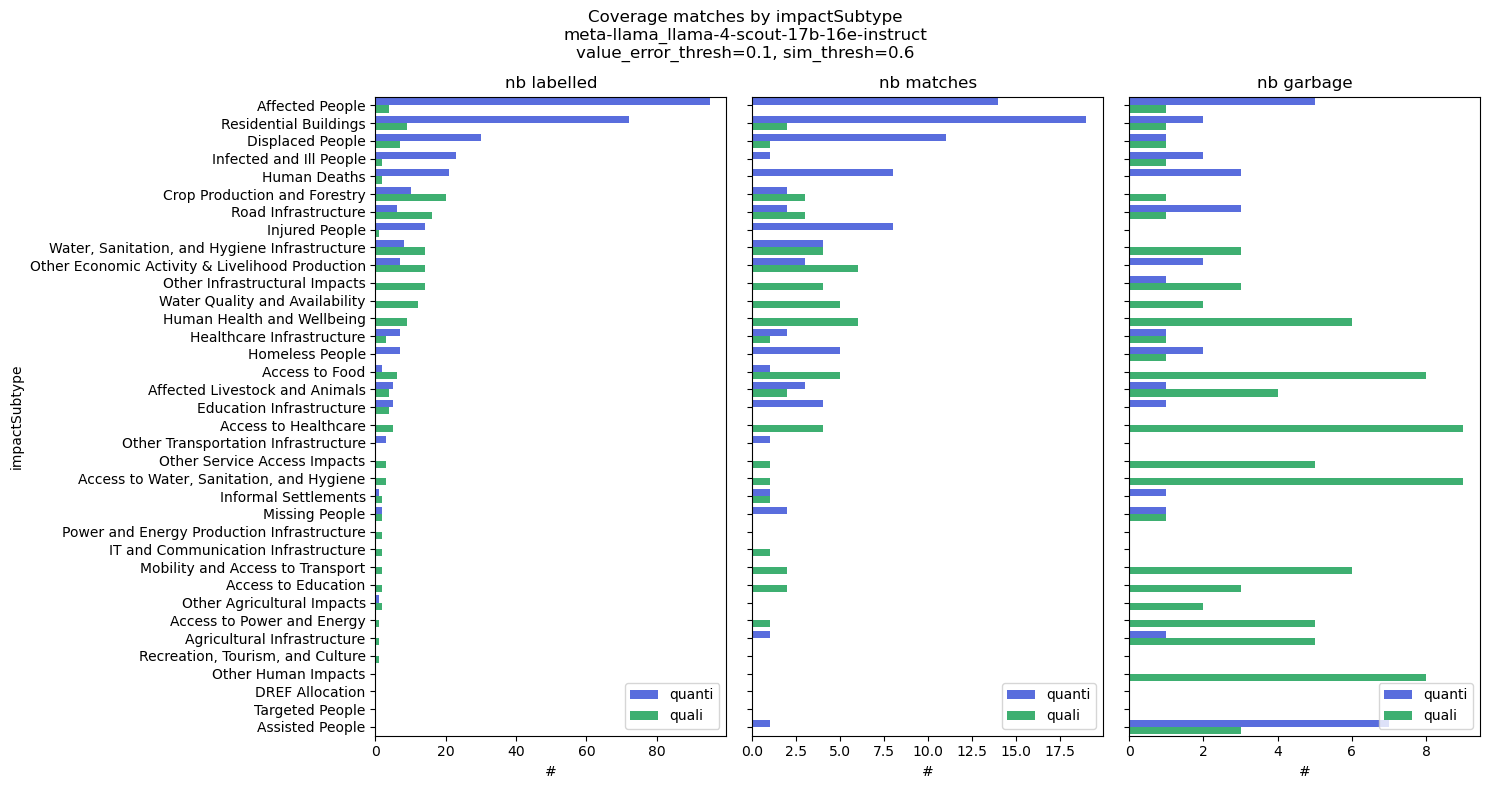

In [28]:
value_vars = ["nb labelled", "nb matches", "nb garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
label = "#"
yvar="impactSubtype"
add_avg = False
if yvar == "appealCode":
    coverage_df_match_yvar = coverage_df_match_appeal
    #sort by to look for trends
    size_index = extracted_df.groupby("appealCode").head(1).sort_values("reportSize", ascending=False)["appealCode"]
    coverage_df_match_yvar["appealCode"] = pd.Categorical(coverage_df_match_yvar["appealCode"], categories=size_index, ordered=True)
    coverage_df_match_yvar = coverage_df_match_yvar.sort_values("appealCode") #sort by size
    plot_df = coverage_df_match_yvar.melt(id_vars=[yvar,"reportSize", "reportDate", "appealType", "quanti"], value_vars=value_vars, var_name="match", value_name="value")

elif yvar == "impactSubtype":
    coverage_df_match_yvar = coverage_df_match_subtype
    coverage_df_match_yvar = coverage_df_match_yvar.sort_values("nb labelled", ascending=False) #sort by nb labelled
    plot_df = coverage_df_match_yvar.melt(id_vars=[yvar, "quanti"], value_vars=value_vars, var_name="match", value_name="value")
if add_avg:
    average_df_match = coverage_df_match.melt(id_vars=["quanti"], value_vars=value_vars, var_name="match", value_name="value")
    average_df_match[yvar] ="Overall average"
    plot_df = pd.concat([average_df_match, plot_df], axis=0).reset_index(drop=True)
#choose plotting cols
subplot_col = "match"#"quanti""match"
hue_col = "quanti"#"quanti""match"
palette_rel = ["#E61F04", "#f46c6c","#177093","#27a4d6"]
palette_rel = ["#435EF3", "#2bc26f","#435EF3", "#2bc26f", "#435EF3", "#2bc26f"]
fig, axes = plot_coverage_match_v2(plot_df, subplot_col, hue_col, yvar=yvar, value_col="value", palette=palette_rel, add_avg=add_avg)
[ax.set_xlabel(label) for ax in axes]
fig.suptitle(f"Coverage matches by {yvar}\n{key}\nvalue_error_thresh={value_error_th}, sim_thresh={sim_th}")
fig.tight_layout()
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_{subplot_col}_vth-{value_error_th}_sth-{sim_th}_flt-{'_'.join(filter_flags)}_{filename_match}.png", bbox_inches="tight", dpi=300)

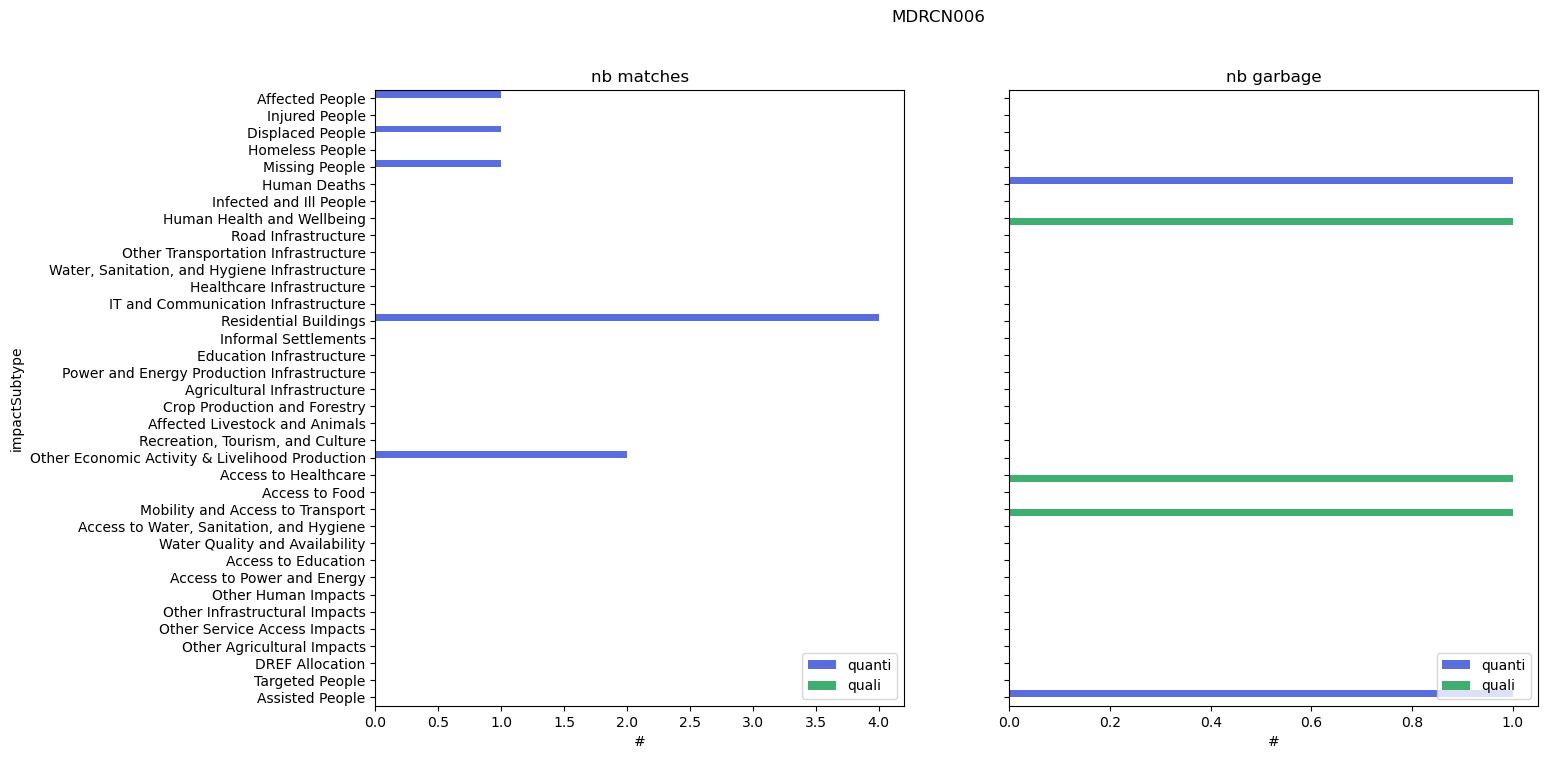

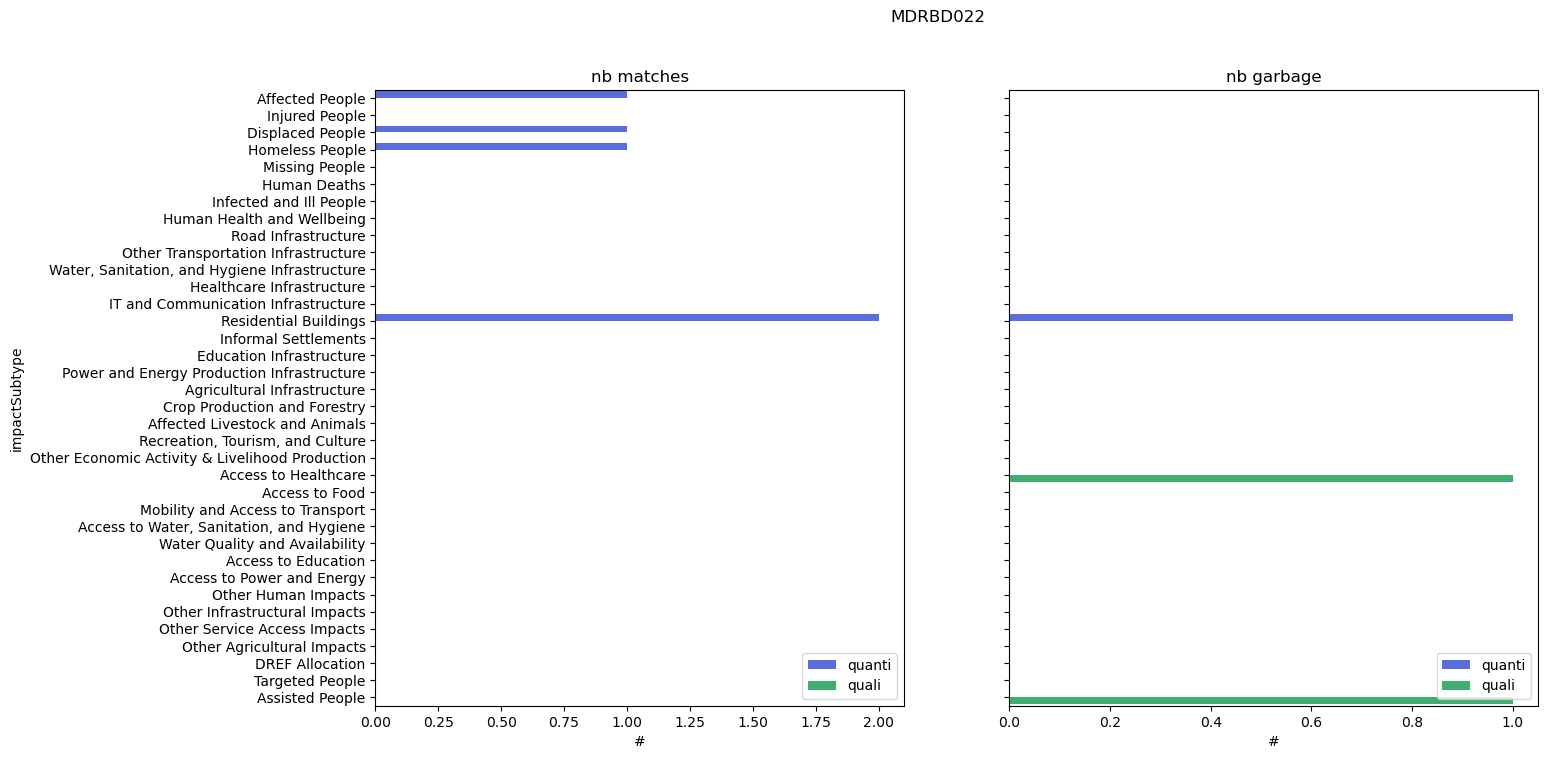

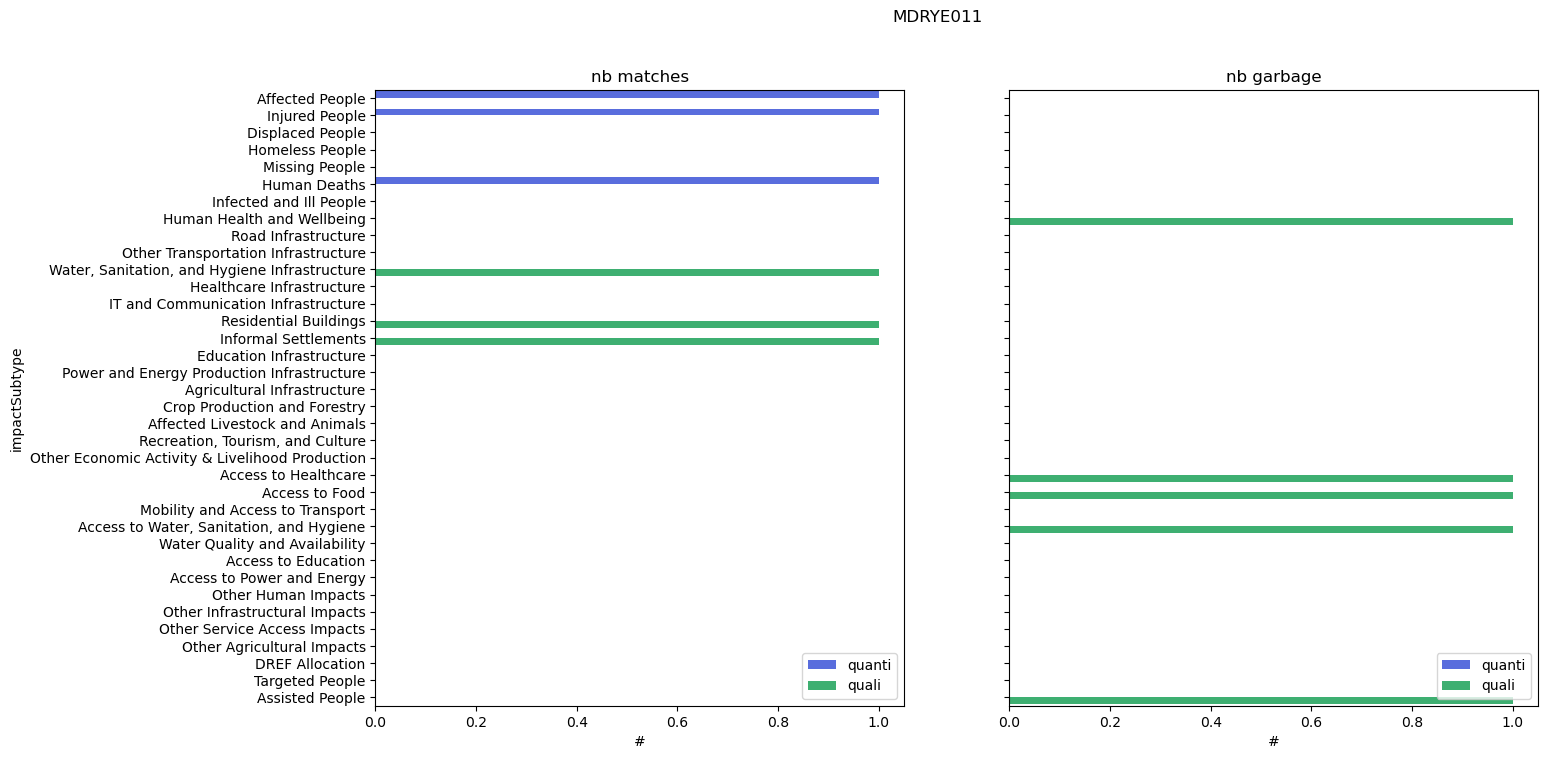

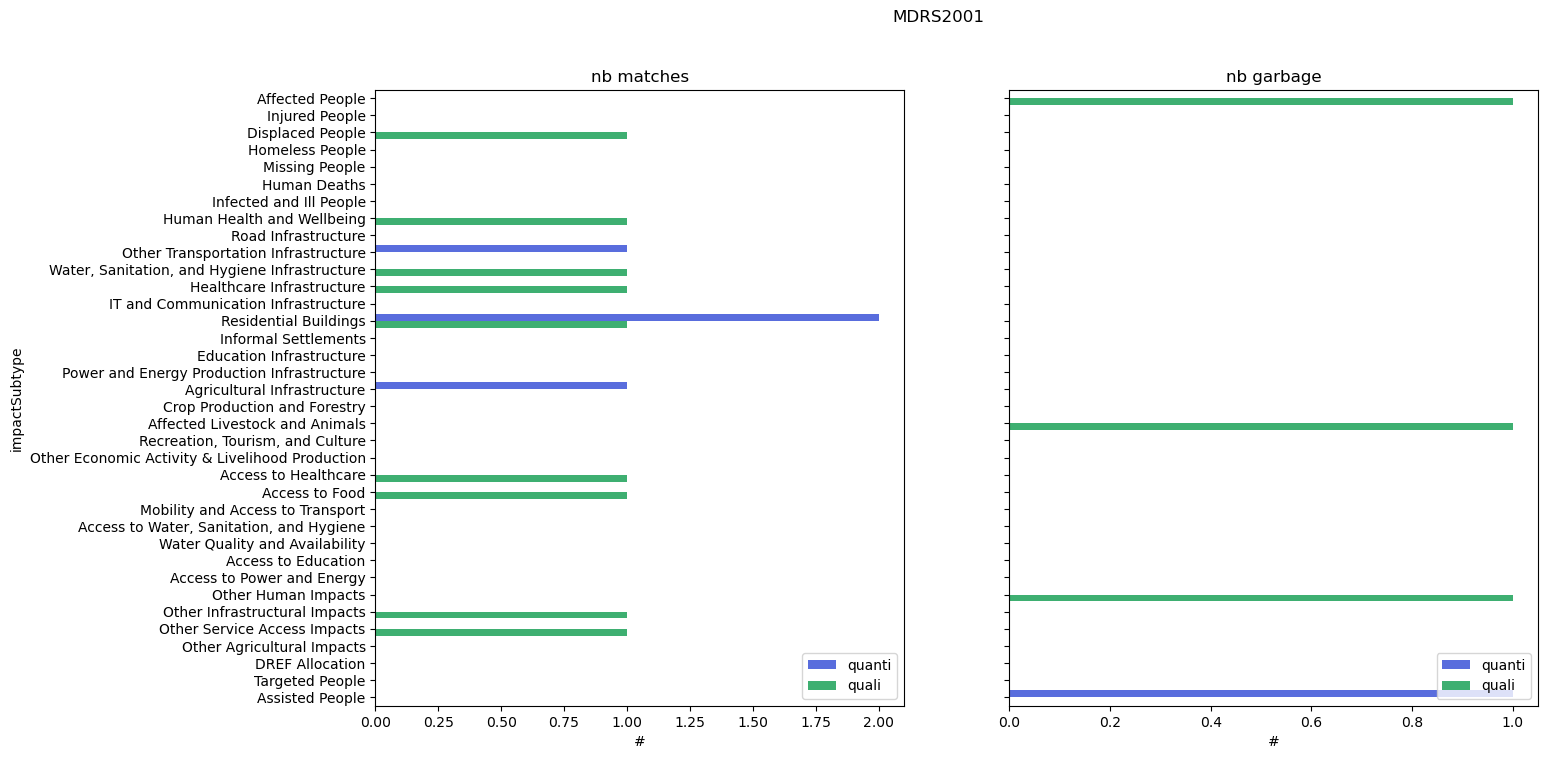

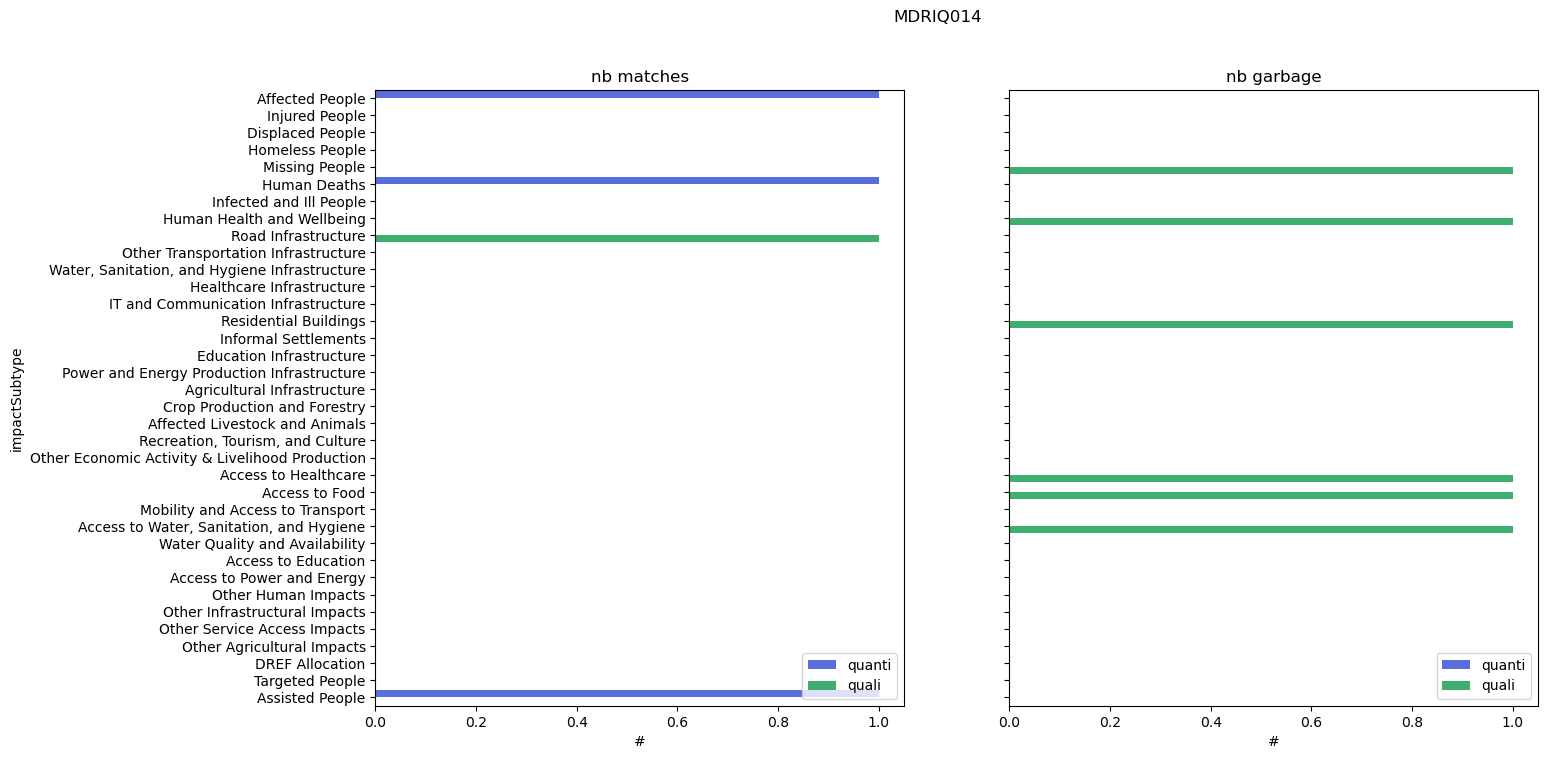

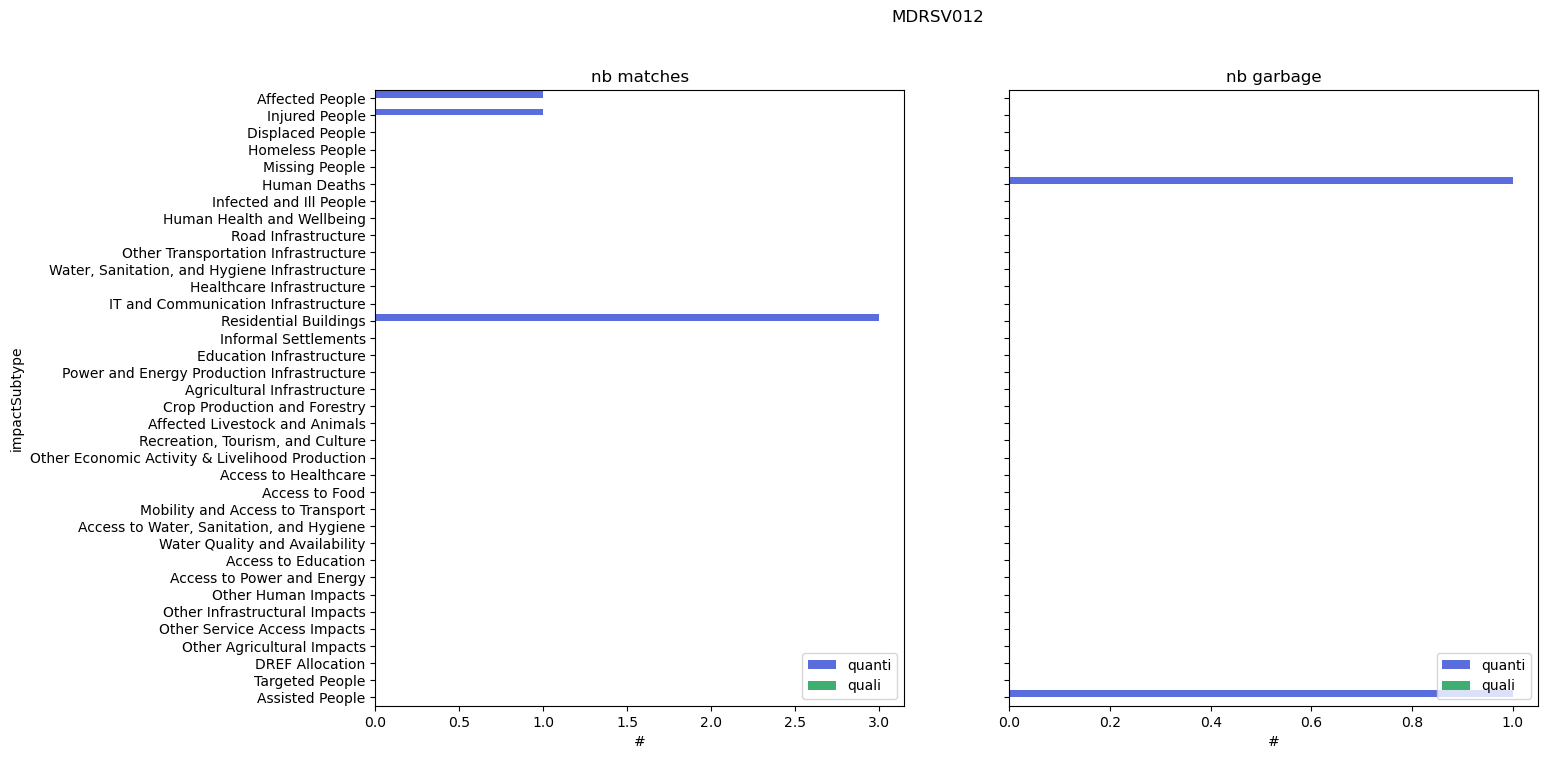

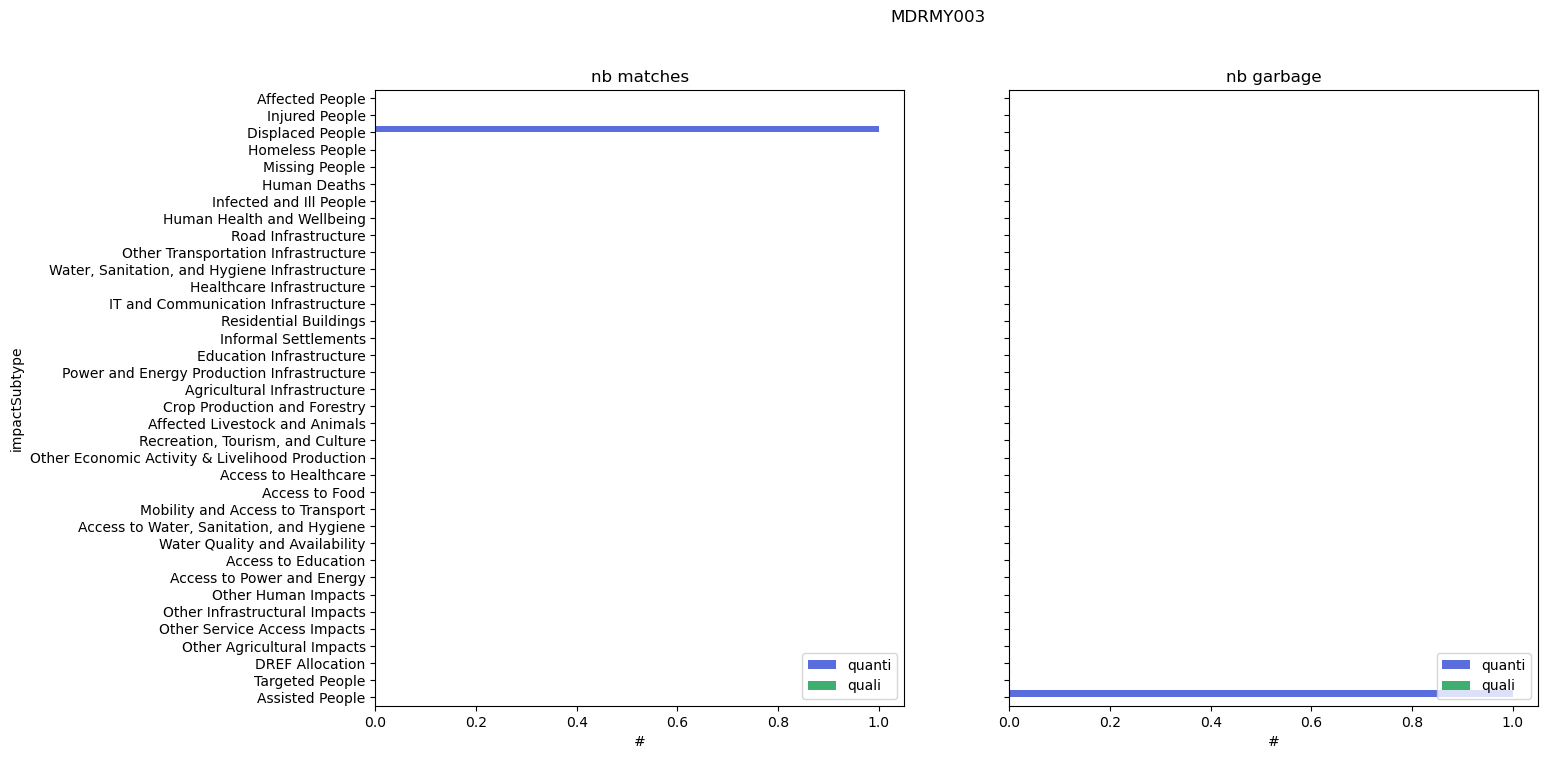

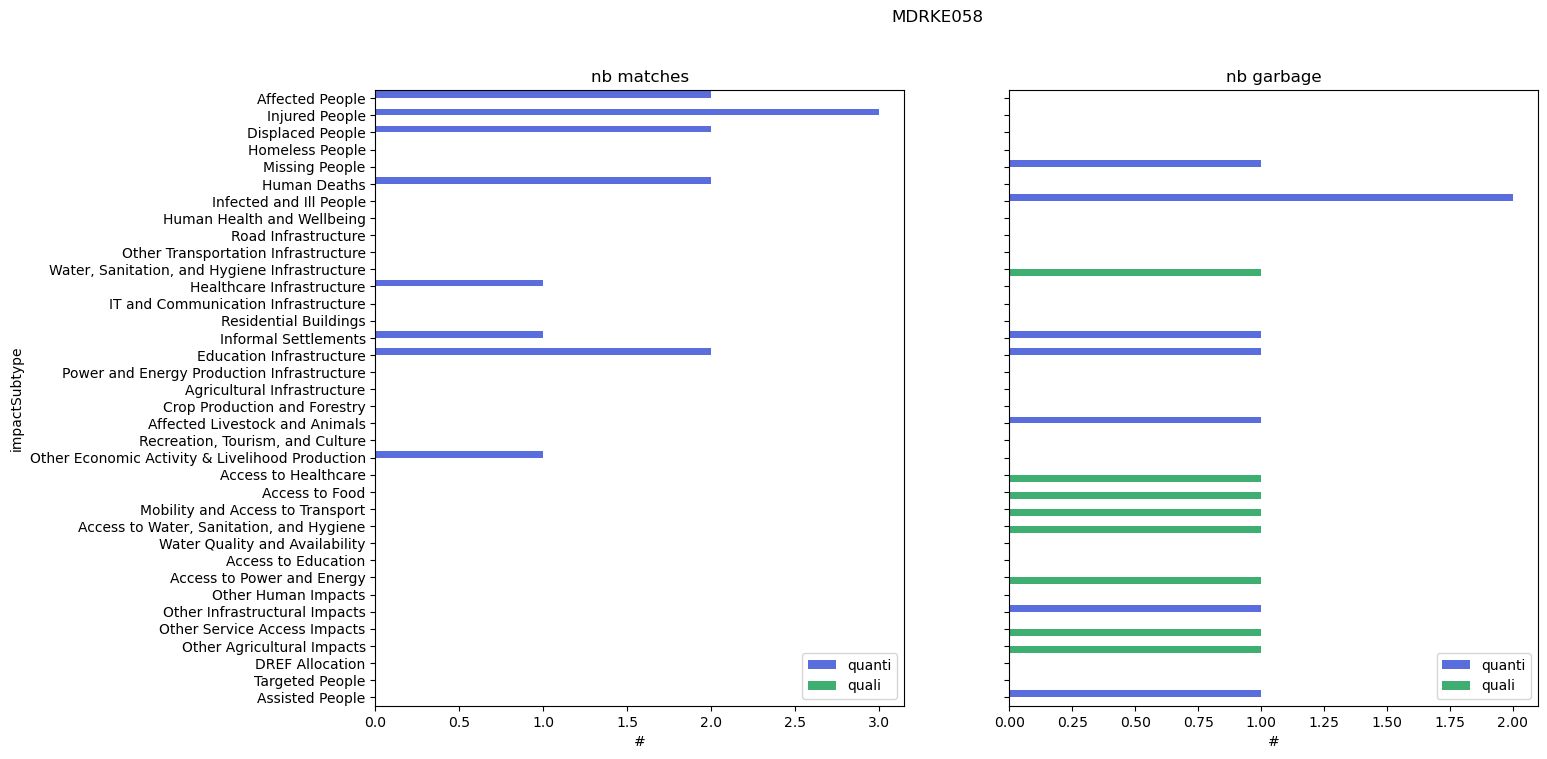

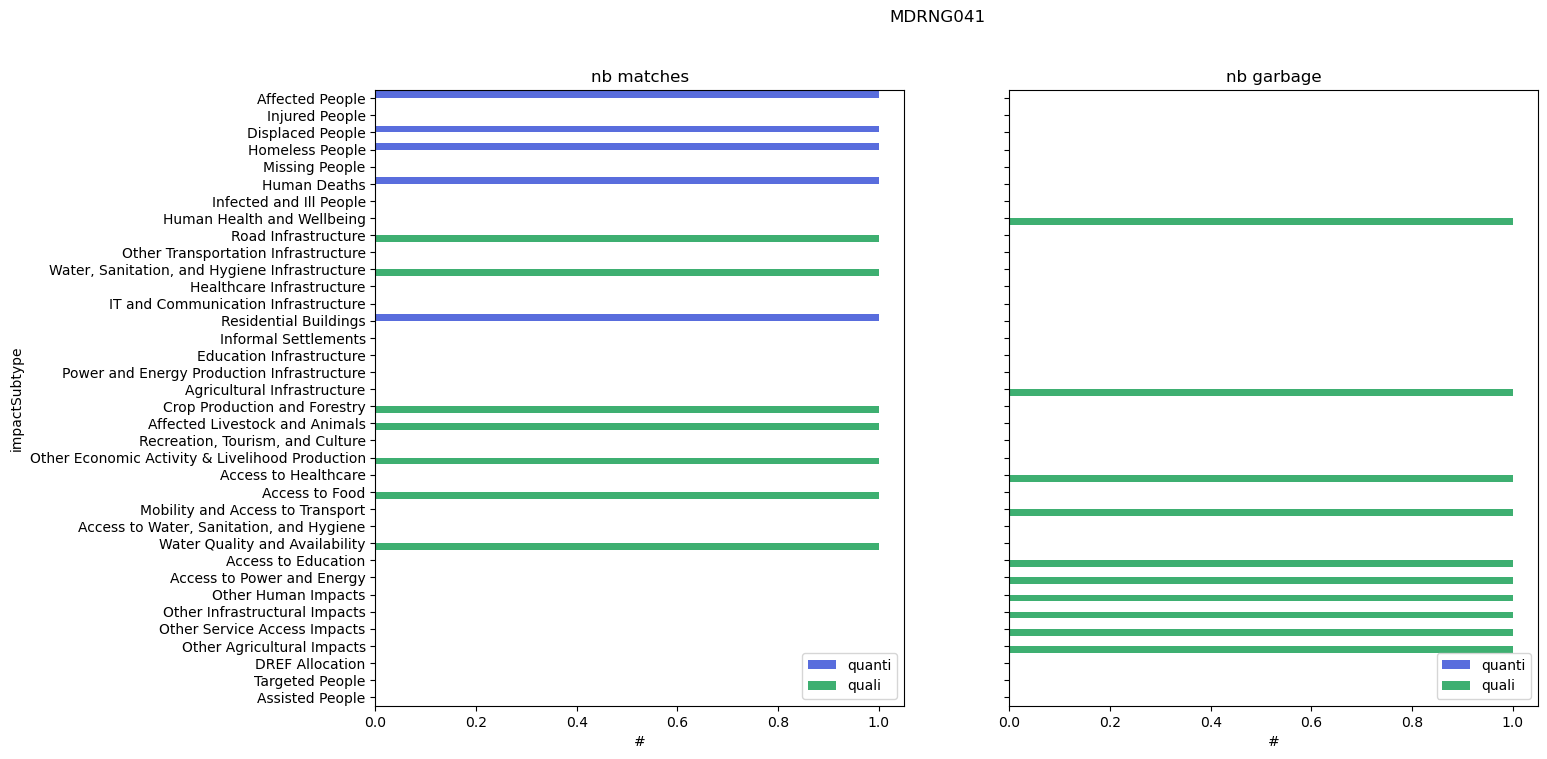

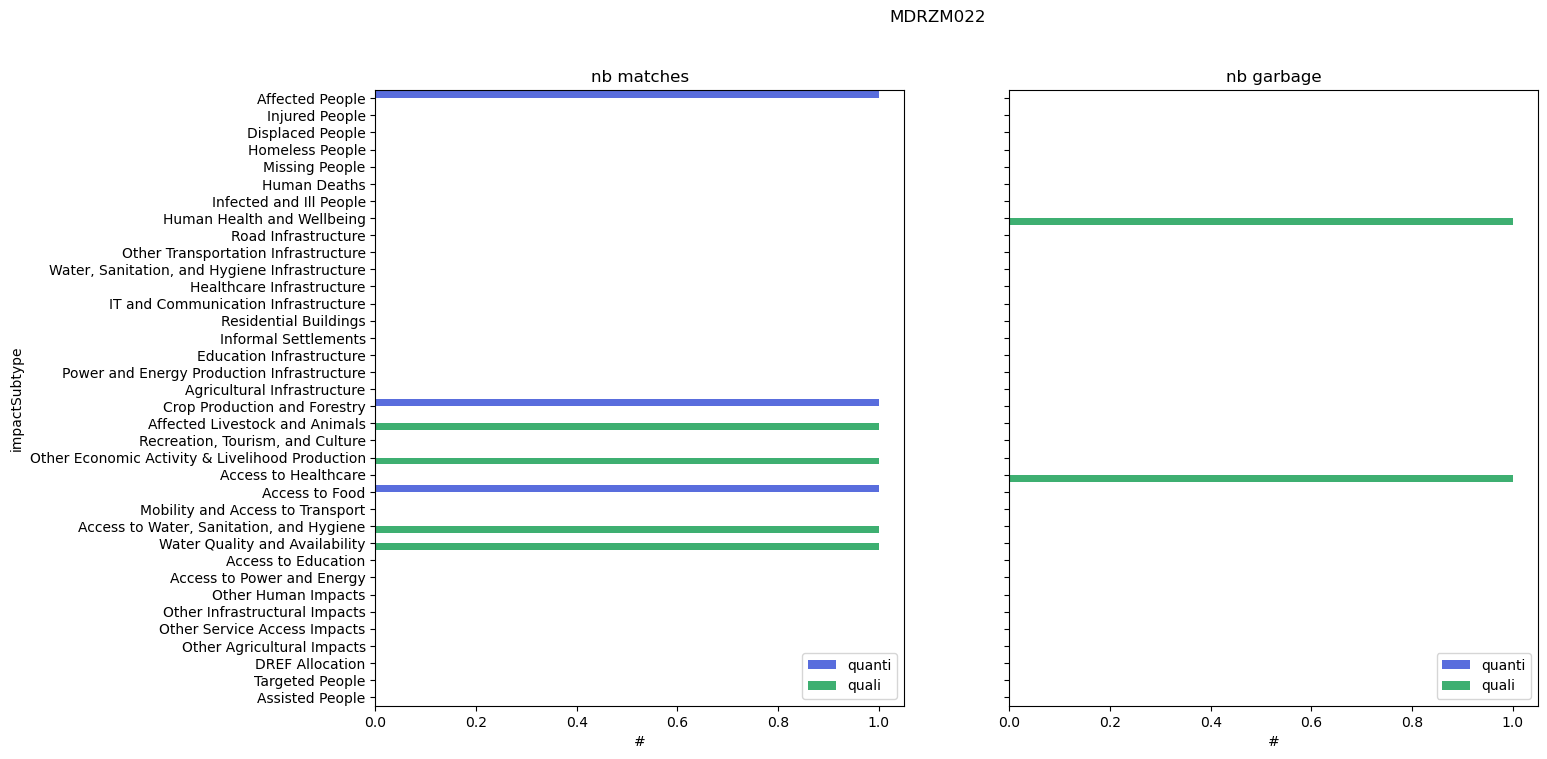

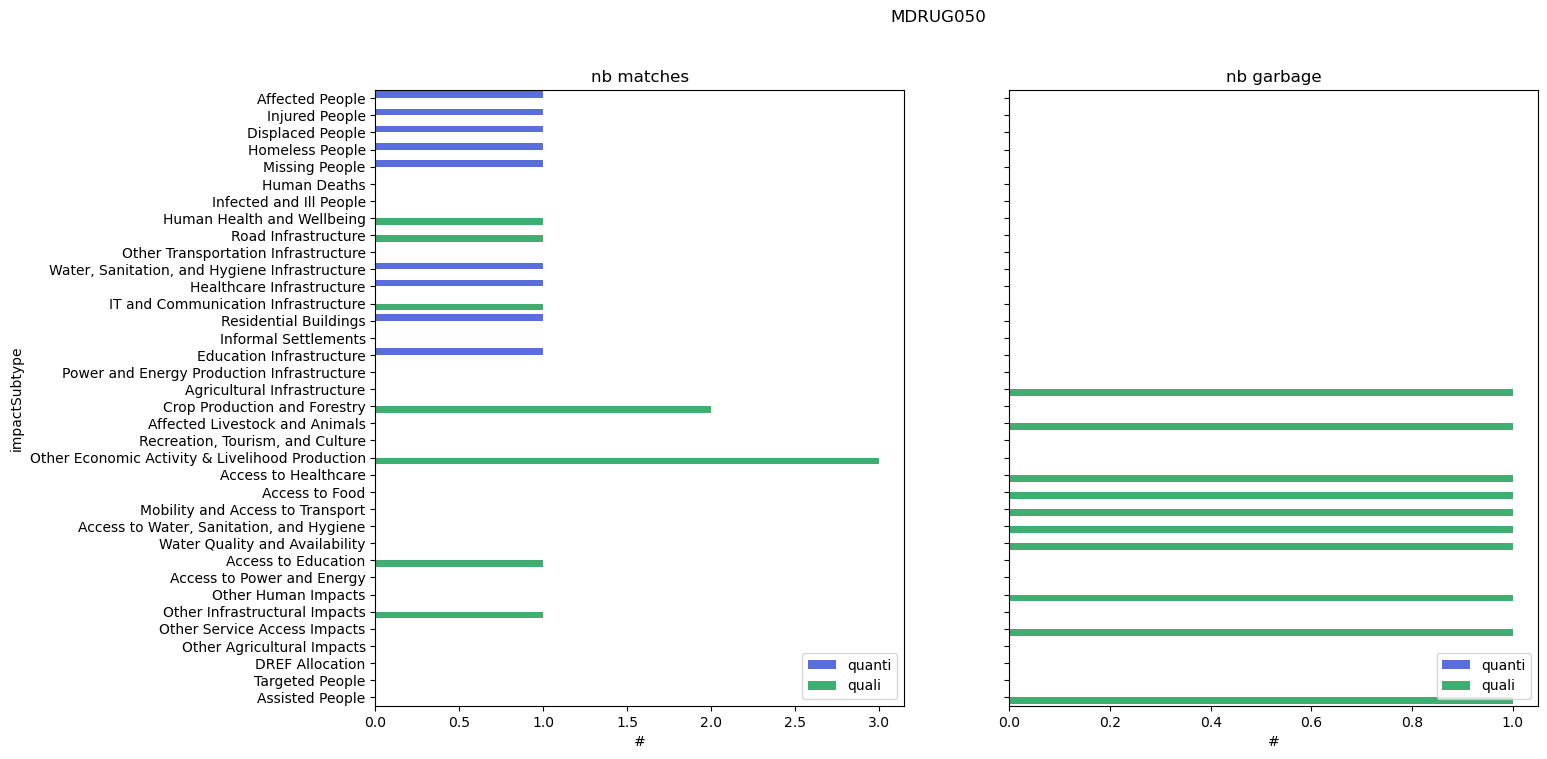

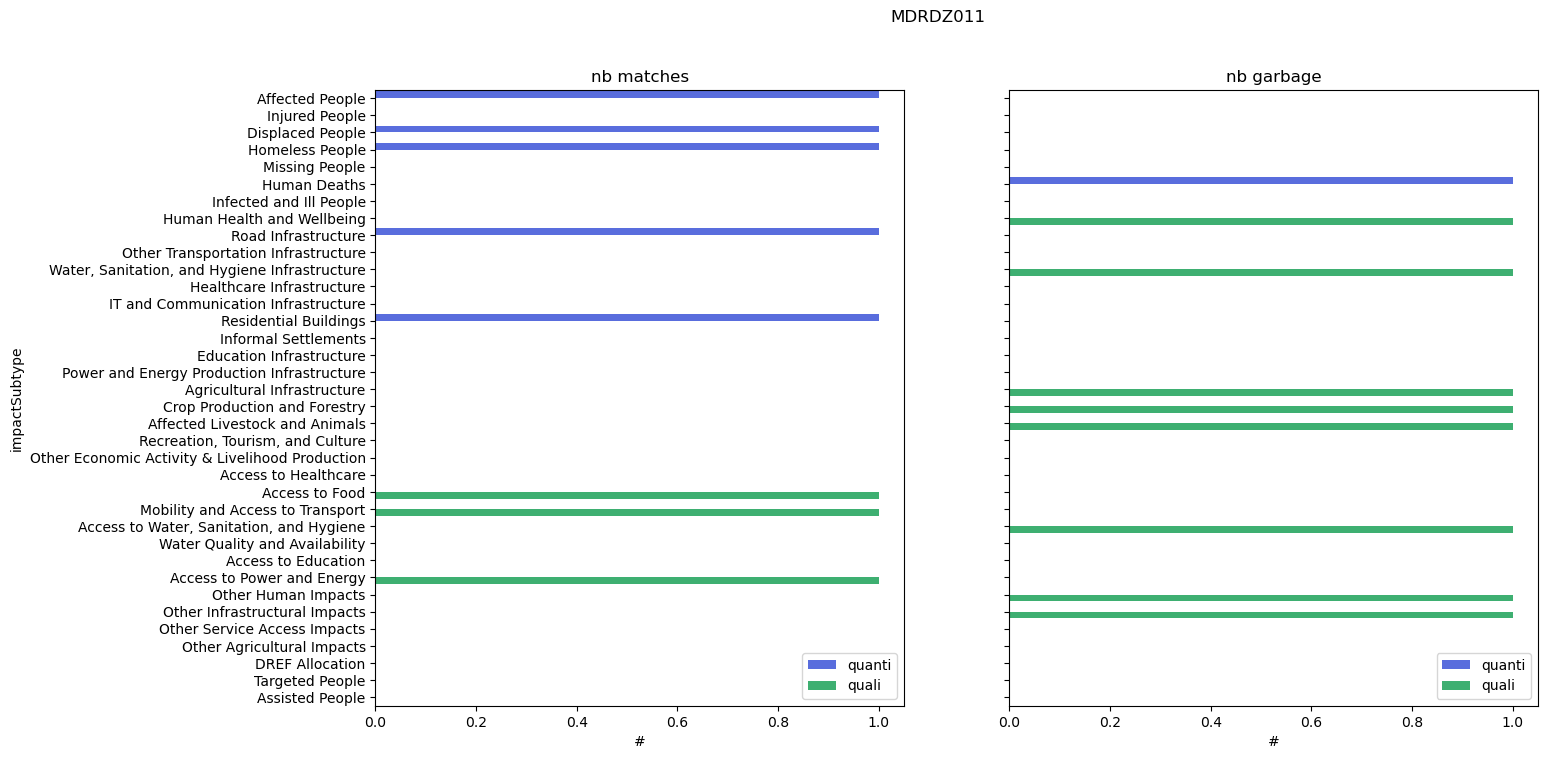

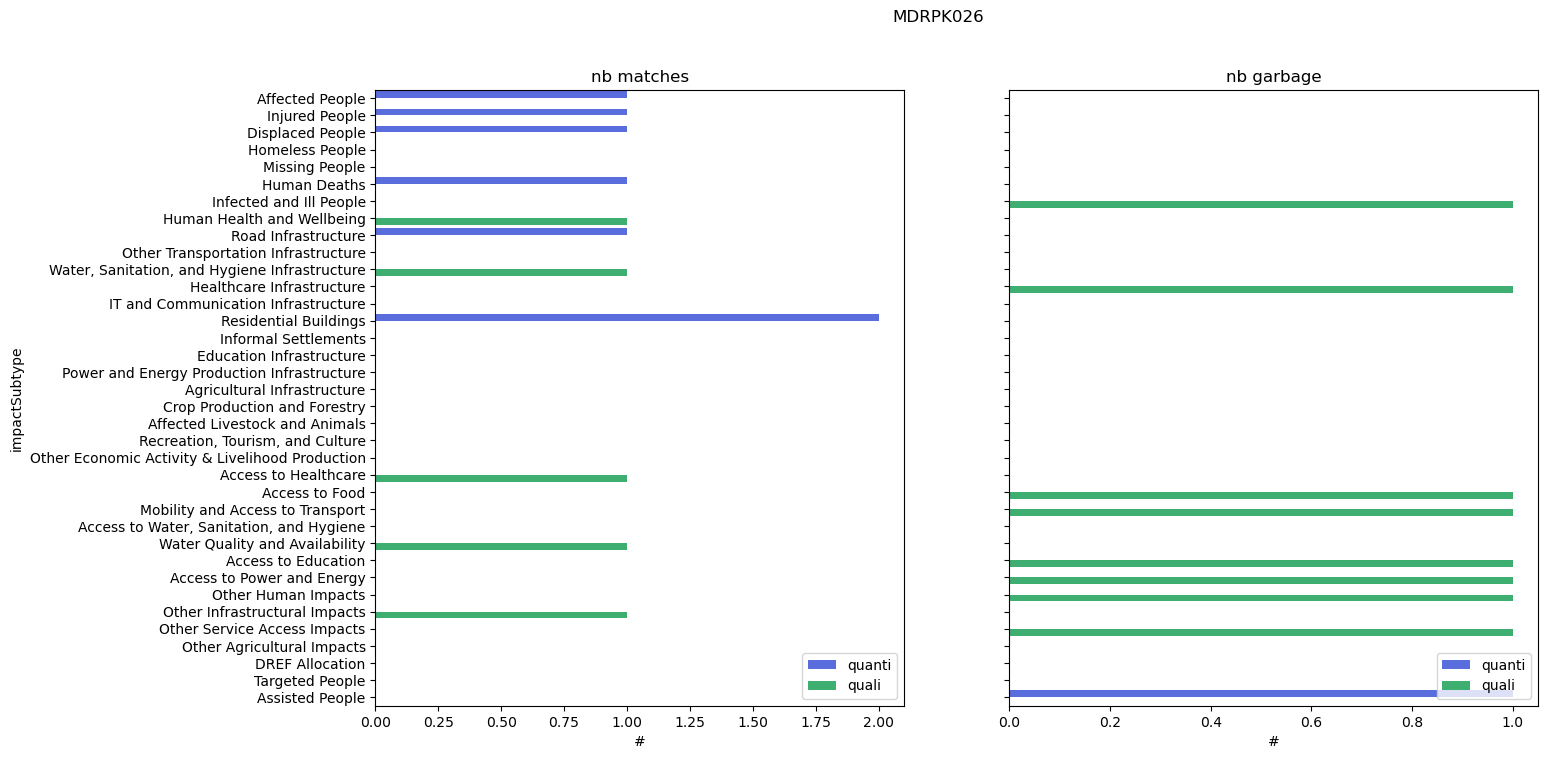

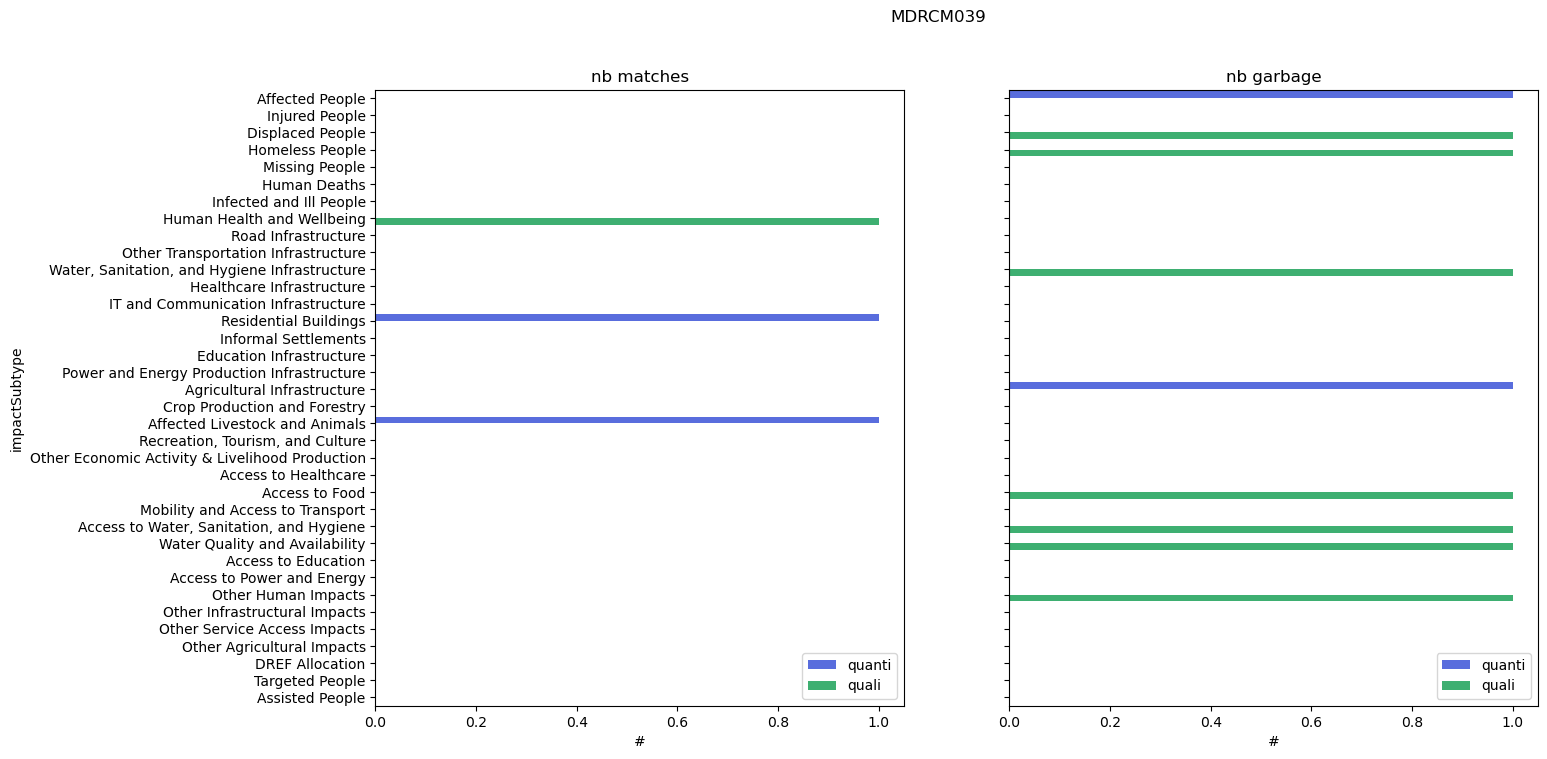

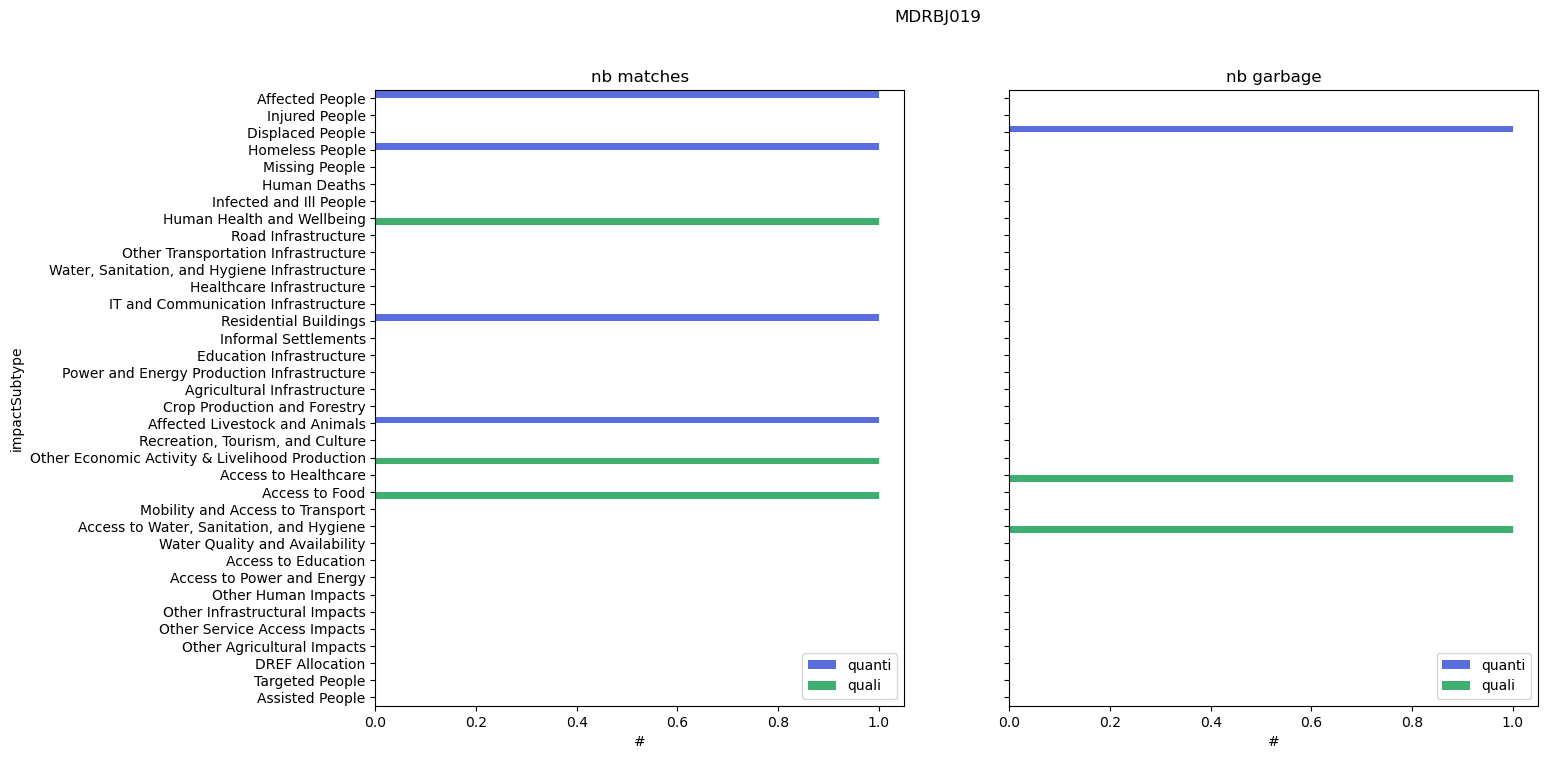

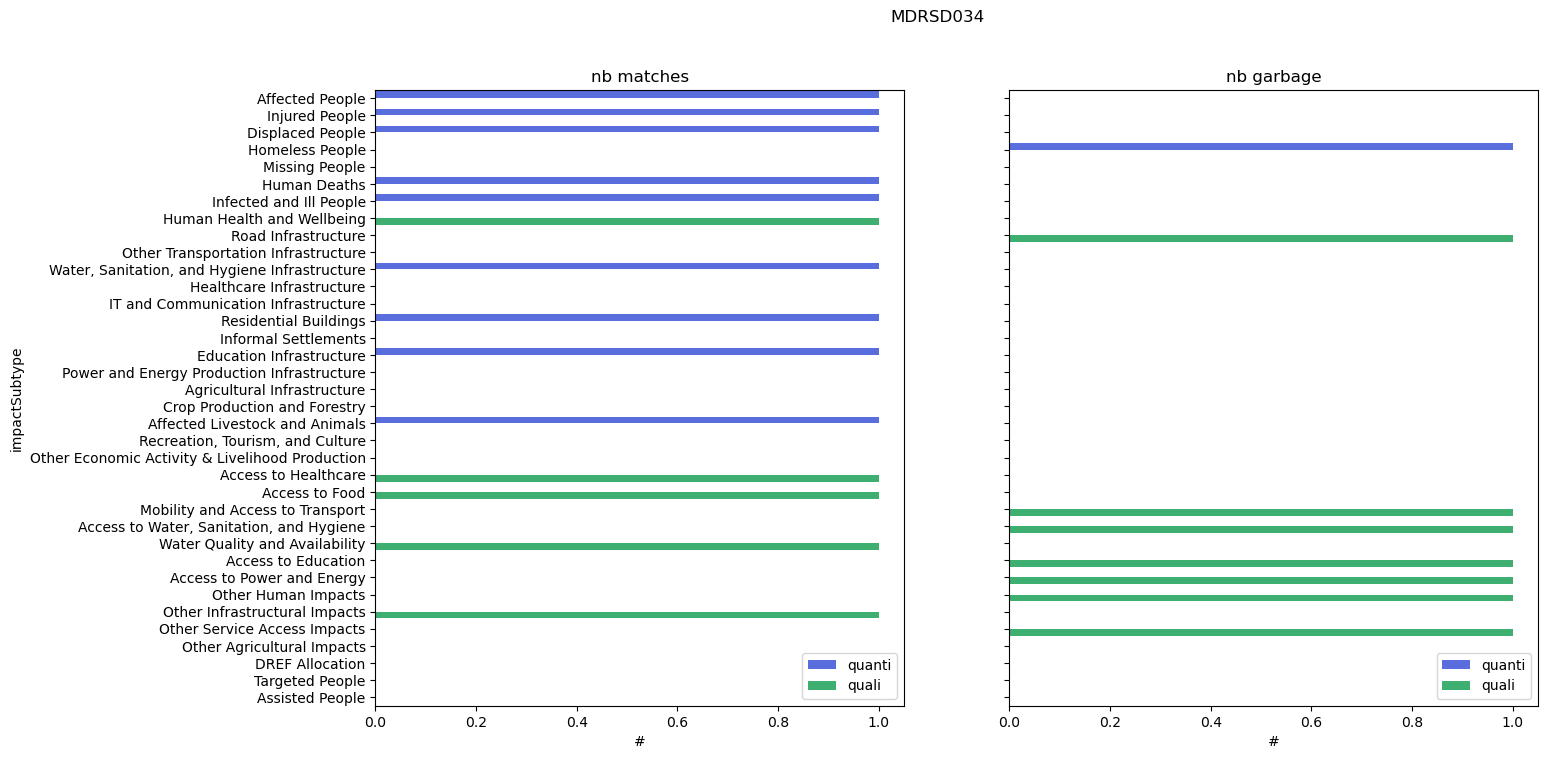

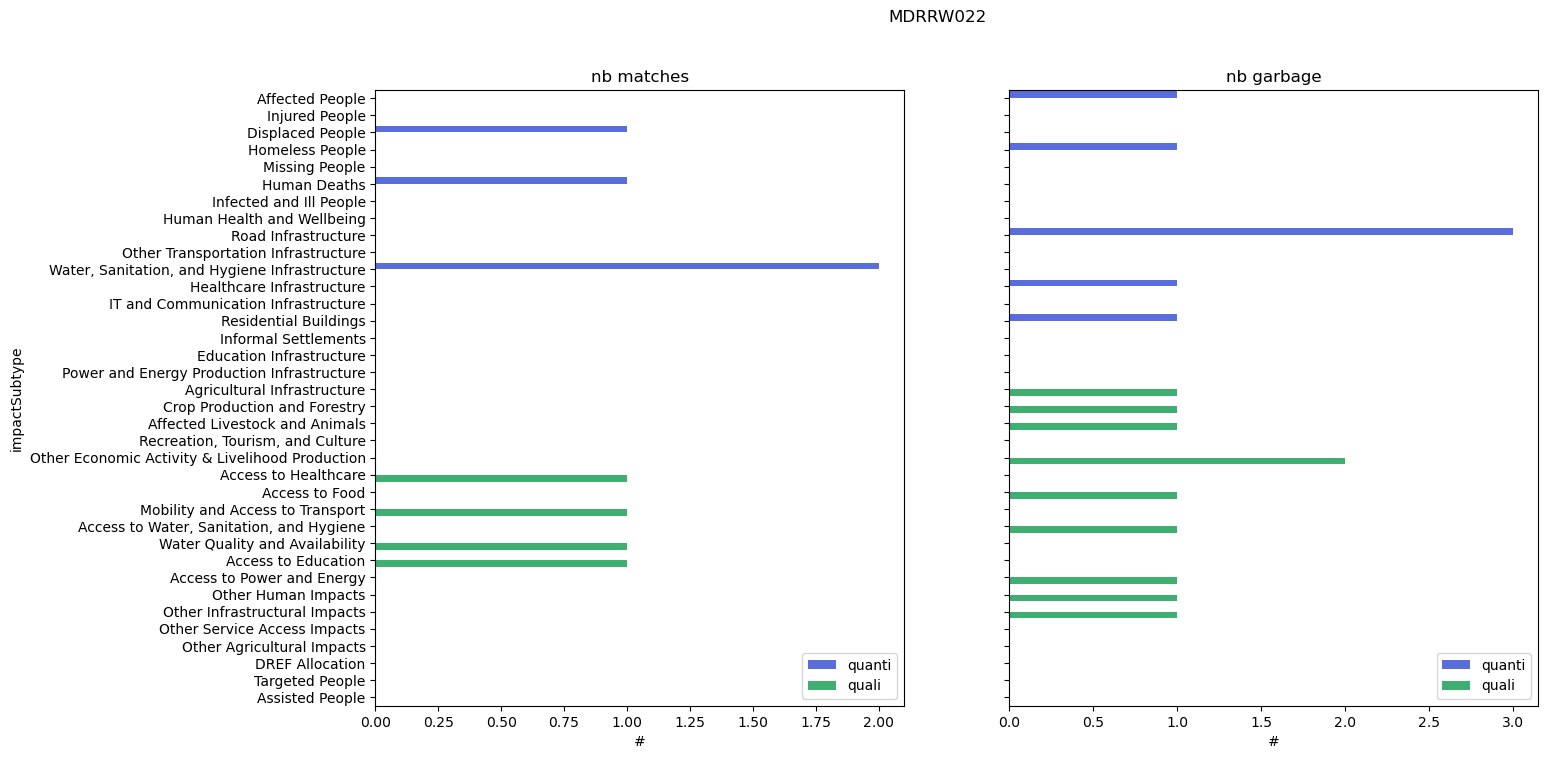

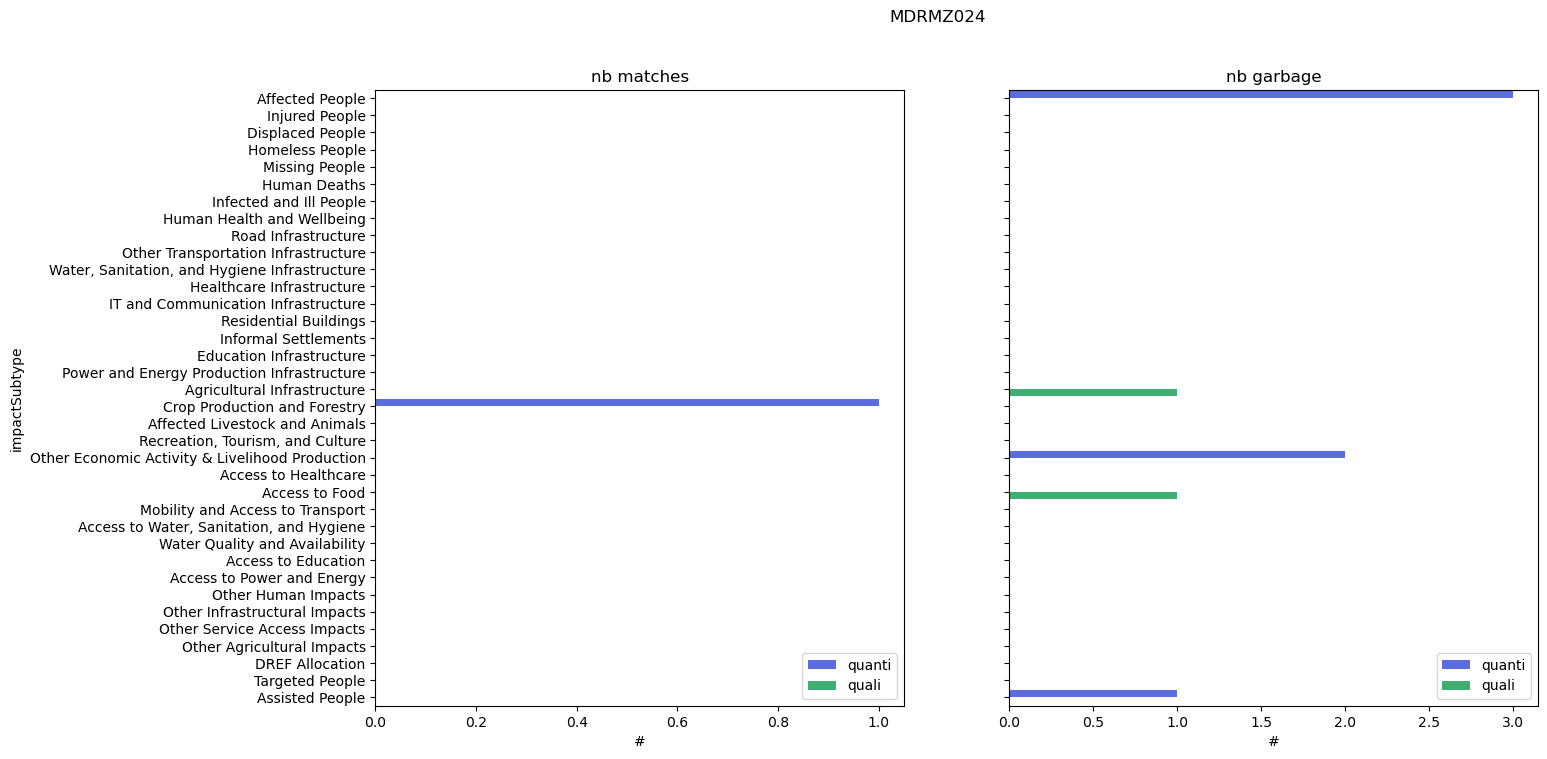

In [19]:
#coverage vs garbage per impactSubtype for each report
appeals = labelled_df.appealCode.unique()
value_vars = ["nb matches", "nb garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
label = "#"
yvar="impactSubtype"
#fig, axes = plt.subplots(len(appeals), 2, figsize=(15, 10), sharey=True)
#choose plotting cols
subplot_col = "match"#"quanti""match"
hue_col = "quanti"#"quanti""match"
palette_rel = ["#E61F04", "#f46c6c","#177093","#27a4d6"]
palette_rel = ["#435EF3", "#2bc26f","#435EF3", "#2bc26f", "#435EF3", "#2bc26f"]

for i, appeal in enumerate(appeals):
    ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
    lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
    matched_appeal = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
    coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES).reset_index(drop=False, names=["impactSubtype"])
    plot_df = coverage_df_match_appeal_subtype.melt(id_vars=[yvar, "quanti"], value_vars=value_vars, var_name="match", value_name="value")
    fig, axes = plot_coverage_match_v2(plot_df, subplot_col, hue_col, yvar=yvar, value_col="value", palette=palette_rel, add_avg=add_avg)
    [ax.set_xlabel(label) for ax in axes]
    fig.suptitle(appeal)

In [26]:
appeal="MDRUG050"
ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
matched_appeal = matched_df[matched_df["appealCode"] == appeal]
matched_appeal_flt = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal_flt, group_key="impactSubtype", group_keys=["Targeted People"]).reset_index(drop=False, names=["impactSubtype"])

In [22]:
coverage_df_match_appeal_subtype

,impactSubtype,nb labelled,nb extracted,coverage,nb matches,coverage matches,nb garbage,garbage,quanti
0,Affected People,17,1,5.882353,1,5.882353,0,0.0,quanti
1,Displaced People,8,1,12.500000,1,12.500000,0,0.0,quanti
2,Residential Buildings,19,1,5.263158,1,5.263158,0,0.0,quanti
3,Crop Production and Forestry,0,0,NaN,0,NaN,0,0.0,quanti
4,Other Infrastructural Impacts,0,0,NaN,0,NaN,0,0.0,quanti
5,Homeless People,5,1,20.000000,1,20.000000,0,0.0,quanti
6,"Water, Sanitation, and Hygiene Infrastructure",3,1,33.333333,1,33.333333,0,0.0,quanti
7,Education Infrastructure,1,1,100.000000,1,100.000000,0,0.0,quanti
8,Road Infrastructure,0,0,NaN,0,NaN,0,0.0,quanti
9,Other Economic Activity & Livelihood Production,0,0,NaN,0,NaN,0,0.0,quanti


In [23]:
print_match(matched_appeal[matched_appeal["match_sim"] < 0.6])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
506,MDRUG050,Targeted people,Affected People,19098.0,18323.0,people,people,"['Central Region', 'Eastern Region', 'Western ...","['Eastern Uganda-Elgon', 'Mbale', 'Kapchorwa',...",0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.585635,['URCS is requesting an additional allocation ...,['Appeal MDRUG050 Total DREF Allocation CHF 47...
509,MDRUG050,Agricultural Infrastructure,Crop Production and Forestry,NaN,NaN,null,null,"['Ntoroko District', 'Bweramule Sub-County', '...","['Eastern Uganda-Elgon', 'Mbale', 'Kapchorwa',...",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.590164,['The flooding has created significant gaps th...,['Appeal MDRUG050 Total DREF Allocation CHF 47...
510,MDRUG050,Agricultural Infrastructure,Other Infrastructural Impacts,NaN,NaN,null,null,"['Ntoroko District', 'Bweramule Sub-County', '...","['Eastern Uganda-Elgon', 'Mbale', 'Kapchorwa',...",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.590164,['The flooding has created significant gaps th...,['Appeal MDRUG050 Total DREF Allocation CHF 47...
513,MDRUG050,Affected Livestock and Animals,Crop Production and Forestry,NaN,NaN,null,null,['Ntoroko District'],"['Eastern Uganda-Elgon', 'Mbale', 'Kapchorwa',...",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.816497,0.551361,['The recent flooding in Ntoroko District has ...,['Appeal MDRUG050 Total DREF Allocation CHF 47...
514,MDRUG050,Affected Livestock and Animals,Other Infrastructural Impacts,NaN,NaN,null,null,['Ntoroko District'],"['Eastern Uganda-Elgon', 'Mbale', 'Kapchorwa',...",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.816497,0.551361,['The recent flooding in Ntoroko District has ...,['Appeal MDRUG050 Total DREF Allocation CHF 47...
518,MDRUG050,Access to Healthcare,Human Health and Wellbeing,NaN,NaN,null,null,"['Ntoroko District', 'Bweramule Sub-County', '...",['Ntoroko District'],0.0,...,1.0,1.0,0.0,1.0,1.0,0.0,0.577350,0.543520,['Immediate provision of safe and affordable d...,"['Additionally, the displacement of people and..."
519,MDRUG050,Access to Food,Human Health and Wellbeing,NaN,NaN,null,null,"['Ntoroko District', 'Bweramule Sub-County', '...",['Ntoroko District'],0.0,...,1.0,1.0,0.0,1.0,1.0,0.0,0.577350,0.543520,['The disruption of local markets has made it ...,"['Additionally, the displacement of people and..."
520,MDRUG050,Mobility and Access to Transport,Crop Production and Forestry,NaN,NaN,null,null,"['Ntoroko District', 'Butungama Sub-County', '...","['Eastern Uganda-Elgon', 'Mbale', 'Kapchorwa',...",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.816497,0.551361,"['Road networks, have been destroyed, and esse...",['Appeal MDRUG050 Total DREF Allocation CHF 47...
521,MDRUG050,Mobility and Access to Transport,Other Infrastructural Impacts,NaN,NaN,null,null,"['Ntoroko District', 'Butungama Sub-County', '...","['Eastern Uganda-Elgon', 'Mbale', 'Kapchorwa',...",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.816497,0.551361,"['Road networks, have been destroyed, and esse...",['Appeal MDRUG050 Total DREF Allocation CHF 47...
522,MDRUG050,"Access to Water, Sanitation, and Hygiene",Crop Production and Forestry,NaN,NaN,null,null,"['Ntoroko District', 'Bweramule Sub-County', '...","['Eastern Uganda-Elgon', 'Mbale', 'Kapchorwa',...",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.000000,0.573770,['Immediate provision of safe and affordable d...,['Appeal MDRUG050 Total DREF Allocation CHF 47...


In [29]:
print_match(matched_appeal)

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
180,MDRKE058,Human Deaths,Human Deaths,38.000000,38.000000,people,people,[],[],1.0,...,1.0,1.0,1.0,0.0,0.0,1.0,0.707107,0.957610,['Since mid-March it is reported that at least...,['October November December short rains season...
181,MDRKE058,Injured People,Injured People,27.000000,27.000000,people,people,[],[],1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.974004,['Since mid-March it is reported that at least...,['October November December short rains season...
183,MDRKE058,Displaced People,Displaced People,192783.000000,193548.000000,people,people,"['Garissa', 'Tana River', 'Lamu', 'Nairobi', '...",[],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.816497,0.911691,"['Over 139,051 households were affected, 64,51...","['Over 139,051 households were affected, 64,51..."
184,MDRKE058,Affected People,Affected People,417153.000000,417213.000000,people,people,"['Garissa', 'Tana River', 'Lamu', 'Nairobi', '...",[],1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.500000,0.894020,"['Over 139,051 households were affected, 64,51...",['October November December short rains season...
188,MDRKE058,Healthcare Infrastructure,Healthcare Infrastructure,7.000000,7.000000,healthcare structures,healthcare structures,[],[],1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.707107,0.908430,['The economic activities of the areas have be...,['October November December short rains season...
189,MDRKE058,Education Infrastructure,Education Infrastructure,18.000000,18.000000,education structures,education structures,[],[],1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.885246,['The economic activities of the areas have be...,['The economic activities of the areas have be...
190,MDRKE058,Other Economic Activity & Livelihood Production,Other Economic Activity & Livelihood Production,264.000000,264.000000,businesses,businesses,[],[],1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.707107,0.908430,['The economic activities of the areas have be...,['October November December short rains season...
192,MDRKE058,Crop Production and Forestry,Crop Production and Forestry,108.245749,112.167168,km**2 of crop production and forestry,km**2 of crop production and forestry,[],[],1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.707107,0.905460,"['More than 3,401 livestock have been lost and...",['October November December short rains season...
194,MDRKE058,Affected Livestock and Animals,Affected Livestock and Animals,17392.000000,17392.000000,affected animals,affected animals,[],[],1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.707107,0.941217,['October November December short rains season...,['October November December short rains season...
196,MDRKE058,Other Economic Activity & Livelihood Production,Other Economic Activity & Livelihood Production,1300.000000,1300.000000,businesses,businesses,[],[],1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.707107,0.908430,['October November December short rains season...,['October November December short rains season...


In [25]:
print_match(matched_df_filter2[(matched_df_filter2["match_sim"]<0.6) & (matched_df_filter2["appealCode"]=="MDRKE058")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [44]:
print_match(matched_appeal[matched_appeal["impactSubtype"]=="Residential Buildings"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
4,MDRBD022,Residential Buildings,Residential Buildings,98571.0,98571.0,homes,homes,[],"['Kurigram district', 'Gaibandha district', 'L...",1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,"['Situation at a glance, as of 16 July 2019 No...","['of partially damaged house 98,571 No.', 'Six..."
6,MDRBD022,Residential Buildings,Residential Buildings,100000.0,98571.0,homes,homes,[],"['Kurigram district', 'Gaibandha district', 'L...",1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.998812,"['around 100,000 houses destroyed']","['of partially damaged house 98,571 No.', 'Six..."
7,MDRBD022,Residential Buildings,Residential Buildings,3988.0,3988.0,homes,homes,[],"['Kurigram district', 'Gaibandha district', 'L...",1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,"['Situation at a glance, as of 16 July 2019 No...","['of fully damaged house 3,988 No.', 'Six days..."
8,MDRBD022,Residential Buildings,Residential Buildings,3988.0,3988.0,homes,homes,[],"['Kurigram district', 'Gaibandha district', 'L...",1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,"['Situation at a glance, as of 16 July 2019 No...","['of fully damaged house 3,988 No.', 'Six days..."
9,MDRBD022,Residential Buildings,Residential Buildings,98571.0,98571.0,homes,homes,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.999934,"['Situation at a glance, as of 16 July 2019 No...","['of partially damaged house 98,571 No.', 'Six..."


In [11]:
matched_appeal[matched_appeal["impactSubtype"]=="Affected People"]#[["appealCode","impactSubtype", "impactSubtype_matched", "impactValue", "impactValue_matched", "impactUnit", "impactUnit_matched", "location", "location_matched", "impactSubtype_sim", "impactUnit_sim", "geometry_sim","hazards_sim","match_sim","valueAnnotation", "annotation_matched"]]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,country,location,...,endMonth_sim,endDay_sim,impactSubtype_sim,impactUnit_sim,geometry_sim,impactValue_sim,match_sim,impactValue_error,quanti,appealType
423,Affected People,696000.0,NaN,NaN,exact,people,"['As of March 2025, needs remained dire in som...",0,['Sudan'],"['Red Sea', 'North Darfur', 'White Nile', 'Nor...",...,1.0,1.0,1.0,1.0,0.717586,0.999019,0.917988,0.000981,quanti,DREF Operation Update
443,Affected People,460743.0,NaN,NaN,exact,people,"['On 25 August 2024, the data collected indica...",0,['Sudan'],"['Kassala', 'Gedaref', 'Nile', 'Northern', 'Re...",...,0.0,1.0,1.0,1.0,0.489042,0.489396,0.877462,0.510604,quanti,DREF Operation Update


In [45]:
print_match(matched_df_filter1[(matched_df_filter1["match_sim"]<0.6) & (matched_df_filter1["appealCode"]=="MDRBD022")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
11,MDRBD022,Homeless People,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.564102,[],['It is also reported that embankments have be...
12,MDRBD022,Homeless People,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.564102,[],['of union affected 776 Emergency Plan of Acti...
15,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.564102,[],['It is also reported that embankments have be...
16,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.564102,[],['of union affected 776 Emergency Plan of Acti...
17,MDRBD022,Human Health and Wellbeing,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.564102,['Six days of heavy rain and onrush of upstrea...,['It is also reported that embankments have be...
18,MDRBD022,Human Health and Wellbeing,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.564102,['Six days of heavy rain and onrush of upstrea...,['of union affected 776 Emergency Plan of Acti...
19,MDRBD022,"Access to Water, Sanitation, and Hygiene",Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.564102,['embankments have been damaged and inundated ...,['It is also reported that embankments have be...
20,MDRBD022,"Access to Water, Sanitation, and Hygiene",Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.564102,['embankments have been damaged and inundated ...,['of union affected 776 Emergency Plan of Acti...
21,MDRBD022,Access to Food,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.564102,[],['It is also reported that embankments have be...
22,MDRBD022,Access to Food,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.564102,[],['of union affected 776 Emergency Plan of Acti...


In [13]:
print_match(matched_df[(matched_df["impactSubtype"]=="Informal Settlements")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
205,MDRKE058,Informal Settlements,Other Infrastructural Impacts,NaN,NaN,null,null,['Nairobi'],[],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.707107,0.417469,['The floods have also hit the capital in resi...,"['Destroyed infrastructure, health and educati..."
206,MDRKE058,Informal Settlements,Healthcare Infrastructure,NaN,NaN,null,null,['Nairobi'],[],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.707107,0.417469,['The floods have also hit the capital in resi...,"['Destroyed infrastructure, health and educati..."
207,MDRKE058,Informal Settlements,Education Infrastructure,NaN,NaN,null,null,['Nairobi'],[],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.707107,0.417469,['The floods have also hit the capital in resi...,"['Destroyed infrastructure, health and educati..."
208,MDRKE058,Informal Settlements,Affected Livestock and Animals,NaN,NaN,null,null,['Nairobi'],[],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.707107,0.417469,['The floods have also hit the capital in resi...,['Communities reported significant loss of liv...
209,MDRKE058,Informal Settlements,Crop Production and Forestry,NaN,NaN,null,null,['Nairobi'],[],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.707107,0.417469,['The floods have also hit the capital in resi...,['Communities reported significant loss of liv...
210,MDRKE058,Informal Settlements,Other Economic Activity & Livelihood Production,NaN,NaN,null,null,['Nairobi'],[],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.707107,0.417469,['The floods have also hit the capital in resi...,['Communities reported significant loss of liv...
454,MDRSD034,Informal Settlements,Water Quality and Availability,NaN,NaN,null,null,"['Tokar', 'Port Sudan', 'Aqeeq', 'Red Sea Stat...",[],0.0,...,1.0,0.0,1.0,1.0,1.0,0.0,0.577350,0.543520,['The situation directly affected displaced in...,"['Since August, the Ministry of health has str..."
531,MDRYE011,Informal Settlements,Affected People,247.0,189.0,informal settlements,people,[],['Al-Tahreer Square'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.276718,['Based on YRCS and shelter cluster flood trac...,['the heavy rains affected 56 families in Al-K...


In [14]:
print_match(matched_df[(matched_df["impactSubtype"]=="Other Infrastructural Impacts")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
13,MDRBD022,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.891970,['embankments have been damaged and inundated ...,['It is also reported that embankments have be...
14,MDRBD022,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']",1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.891970,['embankments have been damaged and inundated ...,['of union affected 776 Emergency Plan of Acti...
78,MDRCM039,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Logone et Chari division', 'Mayo Danay divis...","['Mayo Danay division', 'Yagoua']",1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.557377,"['Several water points were contaminated, and ...",['The peak of the floods was recorded on Augus...
97,MDRCN006,Other Infrastructural Impacts,Residential Buildings,NaN,NaN,null,homes,"['Sichuan', 'Gansu Province', 'Deyang', 'Miany...","['Sichuan', 'southeast region of Gansu']",0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.707107,0.112964,['The Provincial Disaster Reduction Commission...,"['According to this rapid assessment, heavy ra..."
140,MDRDZ011,Other Infrastructural Impacts,Other Economic Activity & Livelihood Production,NaN,NaN,null,null,['Béchar'],"['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.457824,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
141,MDRDZ011,Other Infrastructural Impacts,Other Service Access Impacts,NaN,NaN,null,null,['Béchar'],"['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.457824,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
142,MDRDZ011,Other Infrastructural Impacts,Mobility and Access to Transport,NaN,NaN,null,null,['Béchar'],"['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.457824,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
143,MDRDZ011,Other Infrastructural Impacts,Access to Power and Energy,NaN,NaN,null,null,['Béchar'],"['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.457824,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
144,MDRDZ011,Other Infrastructural Impacts,Water Quality and Availability,NaN,NaN,null,null,['Béchar'],"['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.457824,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
145,MDRDZ011,Other Infrastructural Impacts,Access to Food,NaN,NaN,null,null,['Béchar'],"['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.457824,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...


In [15]:
matched_df[matched_df["match_sim"]<0.6]["impactUnit"].value_counts()

impactUnit
null                         310
people                        19
EUR                           16
children                       9
%                              6
km**2                          3
parcels                        2
people from nomads             1
undefined structures           1
% of undefined structures      1
incidents of heavy rain        1
landslides                     1
overflowed rivers              1
subsidences                    1
informal settlements           1
Name: count, dtype: int64

In [ ]:
extracted_df[extracted_df["appealCode"]=="MDRMZ024"][["impactUnit", "flag_percent"]]

,impactUnit,flag_percent
62,people,False
63,people,False
64,people,False
65,km**2 of crop production and forestry,False
66,null,False
67,EUR,False
68,EUR,False
69,%,True
70,people,False
71,null,False


In [ ]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,flag_percent,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,False,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report


In [ ]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,flag_percent,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,False,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report


In [ ]:
from src.LLM_functions import deduplicate_structured_responses
prev_resp = [ext_appeal.loc[id].to_dict() for id in [298,302]]
new_resp = [ext_appeal.loc[id].to_dict() for id in [304,305]]
len(deduplicate_structured_responses(prev_resp, new_resp))

0

In [ ]:
deduplicate_structured_responses([{"impactSubtype": "Affected People", "impactValue": 100, "impactUnit": "percent"},
                                 {"impactSubtype": "Affected People", "impactValue": np.nan, "impactUnit": np.nan},
                                 {"impactSubtype": "Affected People", "impactValue": 100, "impactUnit": np.nan}],
                                 [{"impactSubtype": "Affected People", "impactValue": 100, "impactUnit": "percent"},
                                 {"impactSubtype": "Affected People", "impactValue": np.nan, "impactUnit": np.nan},
                                 {"impactSubtype": "Affected People", "impactValue": np.nan, "impactUnit": "people"},
                                 {"impactSubtype": "Affected People", "impactValue": 100, "impactUnit": np.nan}])

[{'impactSubtype': 'Affected People',
  'impactValue': nan,
  'impactUnit': 'people'}]

In [ ]:
ids = [[298,305],[302,304]]
for id in ids:
    for col in ext_appeal.loc[id]:
        if ext_appeal.loc[id[0],col] != ext_appeal.loc[id[1],col]:
            print(col, ext_appeal.loc[id[0],col], ext_appeal.loc[id[1],col])

In [ ]:
flag_cols = [col for col in ext_appeal.columns if "flag" in col]

In [ ]:
ext_appeal.loc[[298,305], flag_cols]

,flag_value_not_in_text,flag_impactSubtype_reclass,flag_hazards_reclass,flag_reformat_unit,flag_currency_conversion,flag_unit_standardization,flag_unit_type,flag_unit_harmonization,flag_unit_conversion,flag_unit_nonstd,flag_reclass_subtype_from_unit,flag_pop_cntry,flag_value_no_unit,flag_partial_unit,flag_percent,geocoding_country_flag,geocoding_osm_flag
298,0.0,False,False,False,False,False,False,True,False,False,False,None,False,False,False,0,0
305,0.0,False,False,False,False,False,False,True,False,False,False,None,False,False,False,0,9


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_68870/2555611310.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_68870/2555611310.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_68870/2555611310.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_68870/2555611310.py:10: UserWarning: set_ticklabels() should only be used with a fixed number 

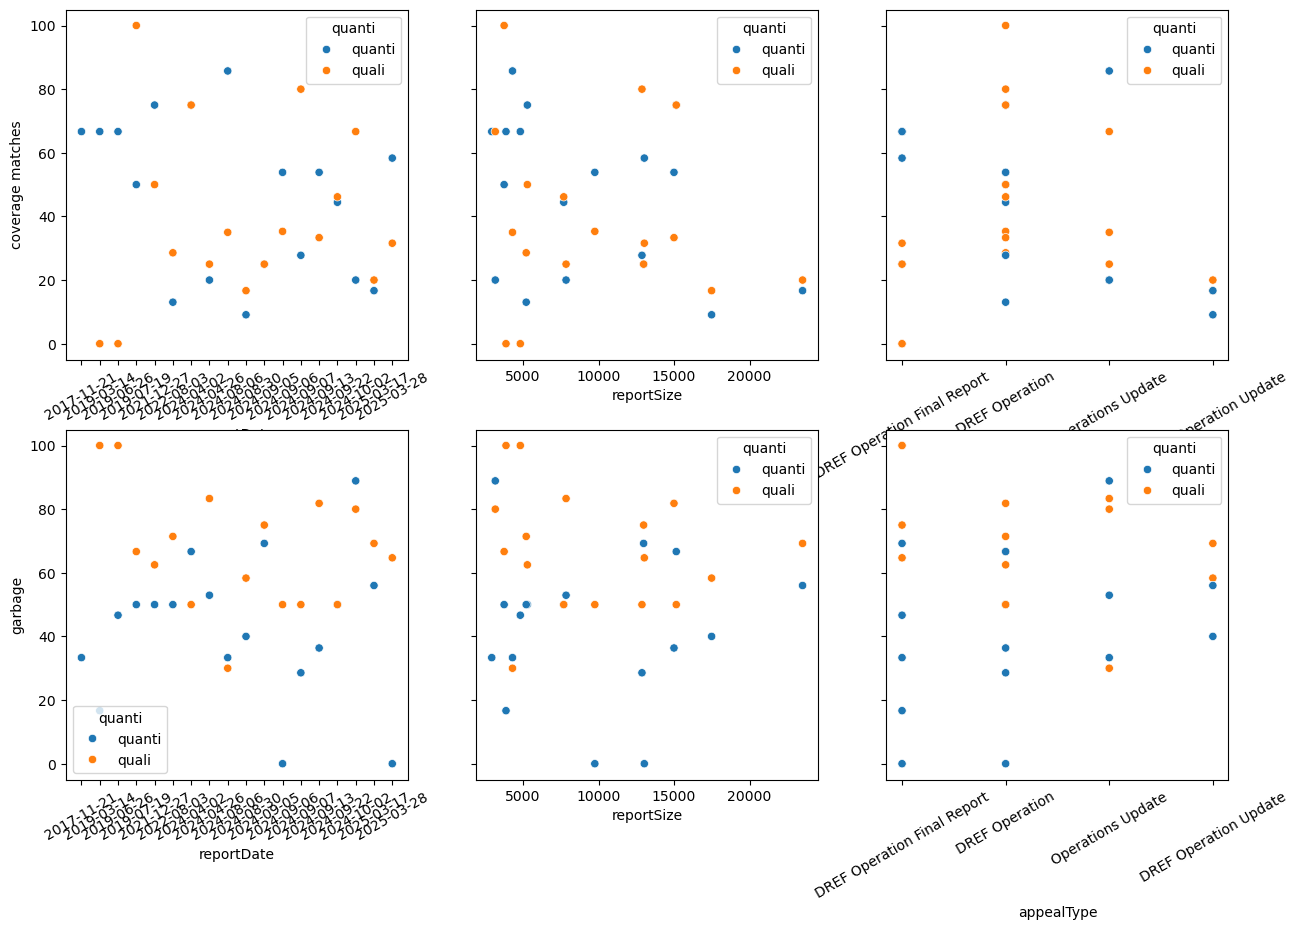

In [ ]:
#inspect sensitivity to other variables e.g. date report type, lentgth
external_vars = ["reportDate", "reportSize", "appealType"]
fig, axes = plt.subplots(2, len(external_vars), figsize=(15, 10), sharey=True)
coverage_df_match_appeal = coverage_df_match_appeal.sort_values("reportDate")
for i, var in enumerate(external_vars):
    sns.scatterplot(coverage_df_match_appeal, x=var, y="coverage matches", hue="quanti", ax=axes[0, i])
    sns.scatterplot(coverage_df_match_appeal, x=var, y="garbage", hue="quanti", ax=axes[1, i])
    if var in ["reportDate", "appealType"]:
        axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_external_vars_valerr_th-{value_error_th}_sim_th-{sim_th}_{filename_match}.png", bbox_inches="tight", dpi=300)

In [ ]:
#inspect sensitivity to thresholds

value_error_ths = np.arange(0.01, 0.3, 0.01)
sim_ths = np.arange(0.2, 1, 0.1)
vth_scores = []
for vth in value_error_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=vth, sim_th=0.6)
    make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None)
    vth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])

sth_scores = []
for sth in sim_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=0.1, sim_th=sth)
    sth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])


Overall average quanti: 184 extracted, 336 labelled, 100 correct matches, 84 garbage matches
Overall average quali: 164 extracted, 174 labelled, 0 correct matches, 164 garbage matches
Overall average quanti: 184 extracted, 336 labelled, 100 correct matches, 84 garbage matches
Overall average quali: 164 extracted, 174 labelled, 0 correct matches, 164 garbage matches
Overall average quanti: 184 extracted, 336 labelled, 102 correct matches, 82 garbage matches
Overall average quali: 164 extracted, 174 labelled, 0 correct matches, 164 garbage matches
Overall average quanti: 184 extracted, 336 labelled, 102 correct matches, 82 garbage matches
Overall average quali: 164 extracted, 174 labelled, 0 correct matches, 164 garbage matches
Overall average quanti: 184 extracted, 336 labelled, 103 correct matches, 81 garbage matches
Overall average quali: 164 extracted, 174 labelled, 0 correct matches, 164 garbage matches
Overall average quanti: 184 extracted, 336 labelled, 103 correct matches, 81 gar

<Axes: >

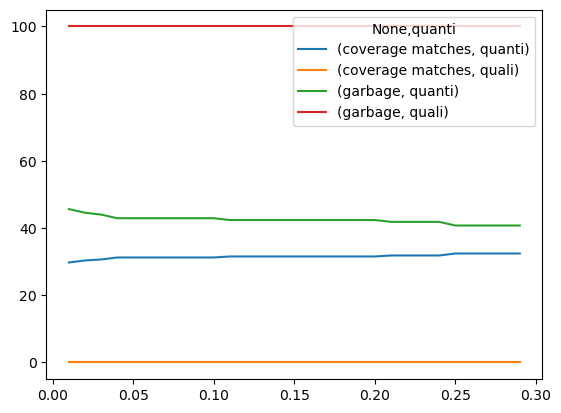

In [ ]:
sensi_vth_df = pd.concat(vth_scores, keys=value_error_ths).unstack()
sensi_vth_df.plot()

<Axes: >

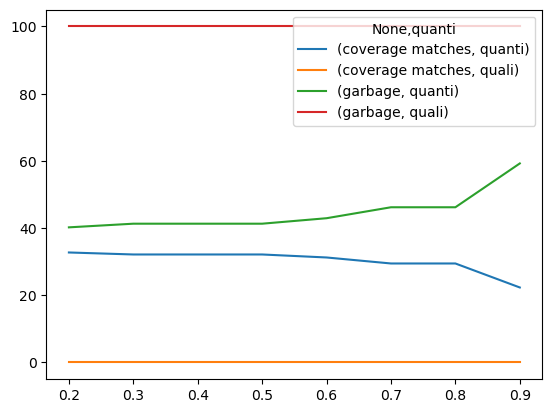

In [ ]:
sensi_sth_df = pd.concat(sth_scores, keys=sim_ths).unstack()
sensi_sth_df.plot()